## City-Specific TCI Prediction with Temporal Cross-Validation

This notebook trains one prediction model for each city to estimate monthly grid-level Traffic Congestion Index (`tci`). Each row in the input data represents one city-grid-month observation. The target is raw `tci`; it is not log-transformed and no tail trimming is applied.

The purpose of this notebook is to make model tuning more temporally rigorous. Instead of choosing hyperparameters from only one validation block, the notebook evaluates candidate models across several expanding-window validation folds inside the model-development period. This checks whether a model performs consistently as the validation month moves forward in time.

Workflow:

1. Load one processed prediction panel for each available city.
2. Build the same predictor groups for every city: environmental variables, static urban variables, POI/road composition features, and geographic context.
3. Use January-October as the model-development period and hold out November-December as the final test period.
4. Tune model type and hyperparameters using expanding-window temporal validation folds inside January-October.
5. Select the candidate with the lowest mean temporal-CV RMSE, while also reporting worst-fold RMSE as a stability diagnostic.
6. Refit the selected model on all January-October development data.
7. Evaluate the final refit model once on the held-out November-December test data.

The test period is never used for model or hyperparameter selection. It is used only for final out-of-sample evaluation.


## 1. Imports and Configuration

This section sets project paths, modelling constants, available cities, output folders, and model-search controls.

Important settings:

- `TARGET_COL = "tci"`: the prediction target.
- `RUN_CITIES`: controls which cities are trained. By default, the notebook can discover all `*_prediction_model_panel.csv` files in `data/PanelProcessed`.
- `SKIP_ALREADY_COMPLETED`: allows incremental runs when some cities have already finished.
- temporal split settings: January-October is used for model development, and November-December is reserved for final testing.

The candidate model families and hyperparameter grids are defined later. Model selection is based on validation RMSE from the temporal cross-validation folds.


In [1]:
from pathlib import Path
import json
import sys
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterSampler
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
    XGBOOST_IMPORT_ERROR = None
except Exception as exc:
    XGBRegressor = None
    XGBOOST_AVAILABLE = False
    XGBOOST_IMPORT_ERROR = exc

try:
    import shap
    SHAP_AVAILABLE = True
    SHAP_IMPORT_ERROR = None
except Exception as exc:
    shap = None
    SHAP_AVAILABLE = False
    SHAP_IMPORT_ERROR = exc

try:
    from statsmodels.stats.diagnostic import acorr_ljungbox
    STATSMODELS_AVAILABLE = True
    STATSMODELS_IMPORT_ERROR = None
except Exception as exc:
    acorr_ljungbox = None
    STATSMODELS_AVAILABLE = False
    STATSMODELS_IMPORT_ERROR = exc

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
TARGET_COL = "tci"
CITY_COL = "city"
SPATIAL_ID_COL = "spatial_id"
YEAR_COL = "year"
MONTH_COL = "month"

def find_project_root(start=None) -> Path:
    """Find the NO2_Mobility_Project root from the current notebook location."""
    current = (start or Path.cwd()).resolve()
    candidates = [current, *current.parents]
    for candidate in candidates:
        if (candidate / "data").exists() and (candidate / "ml_model_training_and_evaluation").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the project root. Run this notebook from within the "
        "NO2_Mobility_Project folder or one of its subfolders."
    )


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
PANEL_DIR = DATA_DIR / "PanelProcessed"
OUTPUT_ROOT = DATA_DIR / "ModelOutputs" / "tci_city_models_with_geo_raw_full_range_v28_temporal_cv"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

CITY_PANEL_FILES = {
    path.name.replace("_prediction_model_panel.csv", ""): path
    for path in sorted(PANEL_DIR.glob("*_prediction_model_panel.csv"))
}

if not CITY_PANEL_FILES:
    raise FileNotFoundError(f"No prediction model panels found in {PANEL_DIR}")

SCENARIO_ID = "raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month"

# Main default: run all available cities. For adding a new city later, set RUN_CITIES = ["new_city_name"].
RUN_CITIES = list(CITY_PANEL_FILES)
SKIP_ALREADY_COMPLETED = False

RUN_HYPERPARAMETER_SEARCH = True
N_ITER_PER_MODEL = 15
PERMUTATION_IMPORTANCE_REPEATS = 30
SHAP_SAMPLE_SIZE = 3000
SPATIAL_MORAN_K = 8
SPATIAL_MORAN_PERMUTATIONS = 99

print("Python executable:", sys.executable)
print("Panel directory:", PANEL_DIR)
print("Model output directory:", OUTPUT_ROOT)
print("Scenario ID:", SCENARIO_ID)
print("Configured cities:", list(CITY_PANEL_FILES))
print("Run cities:", RUN_CITIES)
print("Skip already completed:", SKIP_ALREADY_COMPLETED)
print("XGBoost available:", XGBOOST_AVAILABLE)
if not XGBOOST_AVAILABLE:
    print("XGBoost import error:", repr(XGBOOST_IMPORT_ERROR))
print("SHAP available:", SHAP_AVAILABLE)
if not SHAP_AVAILABLE:
    print("SHAP import error:", repr(SHAP_IMPORT_ERROR))
print("statsmodels available:", STATSMODELS_AVAILABLE)
if not STATSMODELS_AVAILABLE:
    print("statsmodels import error:", repr(STATSMODELS_IMPORT_ERROR))


Python executable: /usr/local/bin/python3
Panel directory: NO2_Mobility_Project/data/PanelProcessed
Model output directory: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv
Scenario ID: raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month
Configured cities: ['baghdad', 'buenos_aires', 'cairo', 'dakar', 'lima', 'mexico_city', 'mumbai', 'new_york']
Run cities: ['baghdad', 'buenos_aires', 'cairo', 'dakar', 'lima', 'mexico_city', 'mumbai', 'new_york']
Skip already completed: False
XGBoost available: True
SHAP available: True
statsmodels available: True


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Optional Incremental City Setup

Use this section only when you want to run a subset of cities. For example, if most cities have already been trained and one new city has just been added, set `RUN_CITIES` to that city name and keep `SKIP_ALREADY_COMPLETED=True`.

For a full clean run, leave `RUN_CITIES` as all detected cities and set `SKIP_ALREADY_COMPLETED=False`. This makes the notebook rerun the same workflow for every available city panel.


In [2]:
# Example for future expansion:
# CITY_PANEL_FILES["new_city_name"] = PANEL_DIR / "new_city_name_prediction_model_panel.csv"
# RUN_CITIES = ["new_city_name"]
# SKIP_ALREADY_COMPLETED = False

completed_cities = []
for city in CITY_PANEL_FILES:
    metrics_path = OUTPUT_ROOT / SCENARIO_ID / city / "metrics.csv"
    if metrics_path.exists():
        completed_cities.append(city)

print("Cities with existing completed outputs:", completed_cities)
print("Cities selected for this run:", RUN_CITIES)


Cities with existing completed outputs: []
Cities selected for this run: ['baghdad', 'buenos_aires', 'cairo', 'dakar', 'lima', 'mexico_city', 'mumbai', 'new_york']


## 3. Load City Panels

This section reads the processed monthly prediction panels. Each panel should contain:

- identifiers: `city`, `spatial_id`, `year`, and `month`;
- target variable: `tci`;
- dynamic predictors such as NO₂, temperature, wind speed, holiday count, and month;
- static predictors such as population, building height, roads, public transport, POIs, and power plants;
- geographic coordinates such as grid centroid longitude and latitude.

The loading step prints city-level summaries, including row counts, grid counts, available months, and missing-value patterns. These checks help confirm that each city has enough usable data before model training.


In [3]:
city_panels = {}
load_summary_rows = []

for city in RUN_CITIES:
    path = CITY_PANEL_FILES[city]
    if not path.exists():
        raise FileNotFoundError(f"Missing city panel for {city}: {path}")

    panel = pd.read_csv(path)
    panel[CITY_COL] = panel[CITY_COL].astype(str)
    panel[SPATIAL_ID_COL] = panel[SPATIAL_ID_COL].astype(str)
    panel[YEAR_COL] = pd.to_numeric(panel[YEAR_COL], errors="coerce").astype(int)
    panel[MONTH_COL] = pd.to_numeric(panel[MONTH_COL], errors="coerce").astype(int)
    city_panels[city] = panel

    load_summary_rows.append({
        "city": city,
        "rows": len(panel),
        "spatial_ids": panel[SPATIAL_ID_COL].nunique(),
        "months": sorted(panel[MONTH_COL].unique().tolist()),
        "columns": panel.shape[1],
        "tci_missing_rows": int(panel[TARGET_COL].isna().sum()) if TARGET_COL in panel.columns else np.nan,
        "wind_missing_rows": int(panel["wind_speed"].isna().sum()) if "wind_speed" in panel.columns else np.nan,
        "centroid_lon_missing_rows": int(panel["centroid_lon"].isna().sum()) if "centroid_lon" in panel.columns else np.nan,
        "centroid_lat_missing_rows": int(panel["centroid_lat"].isna().sum()) if "centroid_lat" in panel.columns else np.nan,
    })

load_summary_df = pd.DataFrame(load_summary_rows)
load_summary_path = OUTPUT_ROOT / "loaded_panel_summary.csv"
load_summary_df.to_csv(load_summary_path, index=False)
print("Saved load summary:", load_summary_path)
display(load_summary_df)


Saved load summary: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/loaded_panel_summary.csv


,city,rows,spatial_ids,months,columns,tci_missing_rows,wind_missing_rows,centroid_lon_missing_rows,centroid_lat_missing_rows
0,baghdad,34138,3737,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",30,0,0,0,0
1,buenos_aires,38323,3753,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",30,0,1801,0,0
2,cairo,25959,2964,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",30,0,0,0,0
3,dakar,3681,380,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",30,0,0,0,0
4,lima,10732,1032,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",30,0,0,0,0
5,mexico_city,41319,4680,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",30,0,0,0,0
6,mumbai,3108,506,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",30,0,0,0,0
7,new_york,9467,795,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",30,0,621,0,0


## 4. Feature Engineering with Geographic Context

This section creates the final predictor set used by the models. The target remains raw `tci`; all transformations are applied only to explanatory variables.

The engineered features include:

- log-transformed scale variables, such as population, total road length, total POI count, and total public transport count;
- road-type and POI-category shares, which separate absolute volume from composition;
- raw centroid longitude and latitude;
- city-centered longitude and latitude;
- kilometer-scale east-west and north-south offsets from the city mean centroid;
- distance from each grid cell to the city-center proxy.

The goal is to give the model both local urban structure and broad spatial context while keeping the target definition unchanged.


In [4]:
ROAD_LENGTH_COLS = [
    "road_length_motorway_m",
    "road_length_primary_m",
    "road_length_residential_m",
    "road_length_secondary_m",
    "road_length_tertiary_m",
    "road_length_trunk_m",
    "road_length_unclassified_m",
]

POI_COLS = [
    "poi_business_n_business",
    "poi_commercial_n_commercial",
    "poi_education_n_education",
    "poi_leisure_n_leisure",
]

SPATIAL_BASE_COLS = ["centroid_lon", "centroid_lat"]
SPATIAL_ENGINEERED_COLS = [
    "centroid_lon_centered",
    "centroid_lat_centered",
    "centroid_x_km_from_city_center",
    "centroid_y_km_from_city_center",
    "distance_to_city_center_km",
]

BASE_FEATURE_COLS = [
    "no2",
    "era5_temp",
    "month",
    "centroid_lon",
    "centroid_lat",
    "holiday_is_off_days",
    "wind_speed",
    "population",
    "building_height",
    "pt_count_points",
    "pt_count_lines",
    "pt_count_polygon",
    "pt_total",
    "road_length_motorway_m",
    "road_length_primary_m",
    "road_length_residential_m",
    "road_length_secondary_m",
    "road_length_tertiary_m",
    "road_length_trunk_m",
    "road_length_unclassified_m",
    "road_length_total_m",
    "poi_business_n_business",
    "poi_commercial_n_commercial",
    "poi_education_n_education",
    "poi_leisure_n_leisure",
    "power_plant_n_power_plant",
]


def safe_log1p(series: pd.Series) -> pd.Series:
    return np.log1p(series.clip(lower=0))


def add_engineered_features(df: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    out = df.copy()

    unique_grid_locations = (
        out[[SPATIAL_ID_COL, "centroid_lon", "centroid_lat"]]
        .drop_duplicates(subset=[SPATIAL_ID_COL])
        .dropna(subset=["centroid_lon", "centroid_lat"])
    )
    city_lon_center = unique_grid_locations["centroid_lon"].mean()
    city_lat_center = unique_grid_locations["centroid_lat"].mean()
    km_per_degree_lat = 111.32
    km_per_degree_lon = 111.32 * np.cos(np.deg2rad(city_lat_center))

    out["centroid_lon_centered"] = out["centroid_lon"] - city_lon_center
    out["centroid_lat_centered"] = out["centroid_lat"] - city_lat_center
    out["centroid_x_km_from_city_center"] = out["centroid_lon_centered"] * km_per_degree_lon
    out["centroid_y_km_from_city_center"] = out["centroid_lat_centered"] * km_per_degree_lat
    out["distance_to_city_center_km"] = np.sqrt(
        out["centroid_x_km_from_city_center"] ** 2
        + out["centroid_y_km_from_city_center"] ** 2
    )

    out["log_population"] = safe_log1p(out["population"])
    out["log_pt_total"] = safe_log1p(out["pt_total"])
    out["log_road_length_total_m"] = safe_log1p(out["road_length_total_m"])
    out["log_power_plant_n_power_plant"] = safe_log1p(out["power_plant_n_power_plant"])

    out["poi_total"] = out[POI_COLS].sum(axis=1)
    out["log_poi_total"] = safe_log1p(out["poi_total"])

    road_total = out["road_length_total_m"].replace(0, np.nan)
    for col in ROAD_LENGTH_COLS:
        out[f"{col}_share"] = (out[col] / road_total).fillna(0)

    poi_total = out["poi_total"].replace(0, np.nan)
    for col in POI_COLS:
        out[f"{col}_share"] = (out[col] / poi_total).fillna(0)

    engineered_cols = SPATIAL_ENGINEERED_COLS + [
        "log_population",
        "log_pt_total",
        "log_road_length_total_m",
        "log_power_plant_n_power_plant",
        "poi_total",
        "log_poi_total",
    ]
    engineered_cols += [f"{col}_share" for col in ROAD_LENGTH_COLS]
    engineered_cols += [f"{col}_share" for col in POI_COLS]

    return out, engineered_cols


engineered_city_panels = {}
feature_columns_by_city = {}
feature_audit_rows = []

for city, panel in city_panels.items():
    panel = panel.copy()
    missing_base = [col for col in BASE_FEATURE_COLS + [TARGET_COL] if col not in panel.columns]
    if missing_base:
        raise ValueError(f"{city}: missing required model columns: {missing_base}")

    engineered_panel, engineered_cols = add_engineered_features(panel)
    feature_cols = BASE_FEATURE_COLS + engineered_cols
    engineered_city_panels[city] = engineered_panel
    feature_columns_by_city[city] = feature_cols

    ready = engineered_panel.dropna(subset=[TARGET_COL] + feature_cols).copy()
    feature_audit_rows.append({
        "city": city,
        "rows_loaded": len(engineered_panel),
        "rows_ready_for_model": len(ready),
        "rows_dropped_by_feature_or_target_dropna": len(engineered_panel) - len(ready),
        "target": TARGET_COL,
        "target_transform": "none_raw_tci",
        "target_range_filter": "none_full_range",
        "raw_tci_min": ready[TARGET_COL].min(),
        "raw_tci_max": ready[TARGET_COL].max(),
        "feature_count": len(feature_cols),
    })

feature_audit_df = pd.DataFrame(feature_audit_rows)
feature_audit_path = OUTPUT_ROOT / "feature_engineering_audit.csv"
feature_audit_df.to_csv(feature_audit_path, index=False)

print("Saved feature audit:", feature_audit_path)
print("\nFEATURE ENGINEERING AUDIT")
print(feature_audit_df.to_string(index=False))

print("\nTARGET")
print(f"- target: raw {TARGET_COL}")
print("- target log transform: none")
print("- target range trimming: none")

print("\nGEOGRAPHY FEATURES USED IN FULL MODEL")
for i, col in enumerate(SPATIAL_BASE_COLS + SPATIAL_ENGINEERED_COLS, start=1):
    print(f"{i:02d}. {col}")

print("\nFINAL FEATURE COUNT BY CITY")
for city in feature_columns_by_city:
    print(f"{city}: {len(feature_columns_by_city[city])} features")


Saved feature audit: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/feature_engineering_audit.csv

FEATURE ENGINEERING AUDIT
        city  rows_loaded  rows_ready_for_model  rows_dropped_by_feature_or_target_dropna target target_transform target_range_filter  raw_tci_min  raw_tci_max  feature_count
     baghdad        34138                 34138                                         0    tci     none_raw_tci     none_full_range    15.860630 5.291997e+06             48
buenos_aires        38323                 36522                                      1801    tci     none_raw_tci     none_full_range    28.776455 1.397723e+06             48
       cairo        25959                 25959                                         0    tci     none_raw_tci     none_full_range     4.501672 2.621466e+06             48
       dakar         3681                  3681                                         0    tci     none_raw_tci     none_full

## 5. Development / Test Split and Temporal CV Folds

This notebook separates model development from final testing.

Final test period:

- Test: November-December

Model-development period:

- Development: January-October

Inside the development period, candidate models are evaluated using expanding-window temporal validation folds. Each fold trains only on months before the validation month, so the validation step follows a forward-looking prediction logic.

The fold design is:

- Fold 1: train January-June, validate July
- Fold 2: train January-July, validate August
- Fold 3: train January-August, validate September
- Fold 4: train January-September, validate October

This design uses more than one validation month and therefore gives a more stable view of model performance than relying only on September-October as a single validation block.


In [5]:
DEVELOPMENT_MONTHS = list(range(1, 11))
TEST_MONTHS = [11, 12]

TEMPORAL_CV_FOLDS = [
    {"fold_id": "fold_1", "train_months": [1, 2, 3, 4, 5, 6], "validation_month": 7},
    {"fold_id": "fold_2", "train_months": [1, 2, 3, 4, 5, 6, 7], "validation_month": 8},
    {"fold_id": "fold_3", "train_months": [1, 2, 3, 4, 5, 6, 7, 8], "validation_month": 9},
    {"fold_id": "fold_4", "train_months": [1, 2, 3, 4, 5, 6, 7, 8, 9], "validation_month": 10},
]


def assign_time_split(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["split"] = "unused"
    out.loc[out[MONTH_COL].isin(DEVELOPMENT_MONTHS), "split"] = "development"
    out.loc[out[MONTH_COL].isin(TEST_MONTHS), "split"] = "test"
    return out.loc[out["split"].isin(["development", "test"])].copy()


split_city_panels = {}
split_summary_rows = []

for city, panel in engineered_city_panels.items():
    split_panel = assign_time_split(panel)
    split_city_panels[city] = split_panel

    for split_name, split_df in split_panel.groupby("split"):
        split_summary_rows.append({
            "city": city,
            "split": split_name,
            "rows": len(split_df),
            "spatial_ids": split_df[SPATIAL_ID_COL].nunique(),
            "months": sorted(split_df[MONTH_COL].unique().tolist()),
            "tci_mean": split_df[TARGET_COL].mean(),
            "tci_std": split_df[TARGET_COL].std(),
        })

    required_splits = {"development", "test"}
    found_splits = set(split_panel["split"].unique())
    missing_splits = required_splits - found_splits
    if missing_splits:
        raise ValueError(f"{city}: missing required splits: {missing_splits}")

split_summary_df = pd.DataFrame(split_summary_rows)
split_summary_path = OUTPUT_ROOT / "time_split_summary.csv"
split_summary_df.to_csv(split_summary_path, index=False)

fold_design_df = pd.DataFrame([
    {
        "fold_id": fold["fold_id"],
        "train_months": ",".join(map(str, fold["train_months"])),
        "validation_month": fold["validation_month"],
    }
    for fold in TEMPORAL_CV_FOLDS
])
fold_design_path = OUTPUT_ROOT / "temporal_cv_fold_design.csv"
fold_design_df.to_csv(fold_design_path, index=False)

print("Saved split summary:", split_summary_path)
print("Saved temporal CV fold design:", fold_design_path)
print("Development months:", DEVELOPMENT_MONTHS)
print("Held-out test months:", TEST_MONTHS)
print("Month is included as a numeric feature in the model input.")
display(split_summary_df.sort_values(["city", "split"]))
display(fold_design_df)


Saved split summary: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/time_split_summary.csv
Saved temporal CV fold design: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/temporal_cv_fold_design.csv
Development months: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Held-out test months: [11, 12]
Month is included as a numeric feature in the model input.


,city,split,rows,spatial_ids,months,tci_mean,tci_std
0,baghdad,development,28857,3662,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",85837.798263,270070.227415
1,baghdad,test,5281,3161,"[11, 12]",90274.980326,217611.823843
2,buenos_aires,development,32224,3745,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",19988.960501,50545.597865
3,buenos_aires,test,6099,3244,"[11, 12]",19948.080316,46160.321819
4,cairo,development,21940,2926,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",19892.907348,71424.414571
5,cairo,test,4019,2319,"[11, 12]",20679.422093,61039.615713
6,dakar,development,3176,380,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",19241.879497,38707.871590
7,dakar,test,505,277,"[11, 12]",20519.398763,33190.796343
8,lima,development,8846,1030,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",81551.510536,165771.672780
9,lima,test,1886,971,"[11, 12]",62697.060022,109676.802189


,fold_id,train_months,validation_month
0,fold_1,"1,2,3,4,5,6",7
1,fold_2,"1,2,3,4,5,6,7",8
2,fold_3,"1,2,3,4,5,6,7,8",9
3,fold_4,"1,2,3,4,5,6,7,8,9",10


## 6. Candidate Models and Evaluation Helpers

This section defines the candidate model families, hyperparameter search spaces, and metric functions.

The notebook compares:

- Elastic Net: a regularised linear baseline;
- Random Forest: a bagged tree ensemble;
- HistGradientBoosting: a scikit-learn gradient-boosted tree model;
- XGBoost: a regularised gradient-boosted tree model, if available.

For every city, every candidate model and hyperparameter setting is scored on the same temporal CV folds. The primary selection metric is mean validation RMSE across folds. MAE, R², and worst-fold RMSE are reported as diagnostics, but they do not replace RMSE as the main selection rule.


In [6]:
MODEL_PARAM_SPACES = {
    "elastic_net": {
        "alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
        "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
    },
    "random_forest": {
        "n_estimators": [300, 500, 800],
        "max_depth": [None, 8, 12, 18, 24],
        "min_samples_leaf": [1, 2, 5, 10],
        "min_samples_split": [2, 5, 10],
        "max_features": ["sqrt", 0.5, 0.8, 1.0],
    },
    "hist_gradient_boosting": {
        "learning_rate": [0.02, 0.03, 0.05, 0.08, 0.1],
        "max_iter": [200, 400, 600],
        "max_leaf_nodes": [15, 31, 63],
        "min_samples_leaf": [20, 50, 100],
        "l2_regularization": [0.0, 0.01, 0.1, 1.0],
    },
    "xgboost": {
        "n_estimators": [300, 500, 800],
        "max_depth": [3, 4, 5, 6],
        "learning_rate": [0.02, 0.03, 0.05, 0.08],
        "subsample": [0.7, 0.85, 1.0],
        "colsample_bytree": [0.7, 0.85, 1.0],
        "min_child_weight": [1, 3, 5, 10],
        "gamma": [0.0, 0.1, 0.5, 1.0],
        "reg_lambda": [0.5, 1.0, 3.0, 10.0, 20.0],
        "reg_alpha": [0.0, 0.1, 0.5, 1.0],
    },
}

if not XGBOOST_AVAILABLE:
    MODEL_PARAM_SPACES.pop("xgboost", None)
    print("XGBoost is not available in this kernel, so xgboost is skipped.")
elif not SHAP_AVAILABLE:
    print("XGBoost is available, but SHAP is not available. XGBoost will train without SHAP outputs.")


def build_model(model_name: str, params: dict):
    if model_name == "elastic_net":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", ElasticNet(random_state=RANDOM_STATE, max_iter=20000, **params)),
        ])
    if model_name == "random_forest":
        return RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **params)
    if model_name == "hist_gradient_boosting":
        return HistGradientBoostingRegressor(random_state=RANDOM_STATE, **params)
    if model_name == "xgboost":
        return XGBRegressor(
            objective="reg:squarederror",
            eval_metric="rmse",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method="hist",
            **params,
        )
    raise ValueError(f"Unknown model name: {model_name}")


def evaluate_regression(y_true, y_pred) -> dict:
    return {
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
    }


def evaluate_model(model, X, y) -> dict:
    return evaluate_regression(y, model.predict(X))


def sample_params(model_name: str, n_iter: int) -> list[dict]:
    param_space = MODEL_PARAM_SPACES[model_name]
    if not RUN_HYPERPARAMETER_SEARCH:
        return [{key: values[0] if isinstance(values, list) else values for key, values in param_space.items()}]
    n_possible = np.prod([len(values) for values in param_space.values()])
    n_to_sample = min(n_iter, int(n_possible))
    return list(ParameterSampler(param_space, n_iter=n_to_sample, random_state=RANDOM_STATE))


def predicted_col() -> str:
    return f"predicted_{TARGET_COL}"


def residual_col() -> str:
    return f"{TARGET_COL}_residual"


def prepare_model_panel(panel: pd.DataFrame, feature_cols: list[str]) -> tuple[pd.DataFrame, dict]:
    required_cols = [TARGET_COL] + feature_cols
    before_dropna = len(panel)
    model_panel = panel.dropna(subset=required_cols).copy()
    return model_panel, {
        "rows_before_dropna": before_dropna,
        "rows_after_dropna": len(model_panel),
        "rows_dropped_by_dropna": before_dropna - len(model_panel),
        "range_mode": "full_range",
        "range_label": "raw TCI full range",
        "rows_before_range_filter": len(model_panel),
        "rows_after_range_filter": len(model_panel),
        "rows_dropped_by_range_filter": 0,
    }


def add_prediction_outputs(prediction_df: pd.DataFrame, predictions: np.ndarray) -> pd.DataFrame:
    out = prediction_df.copy()
    out[predicted_col()] = predictions
    out[residual_col()] = out[TARGET_COL] - out[predicted_col()]
    return out


def normalize_shap_values(raw_shap_values) -> np.ndarray:
    if isinstance(raw_shap_values, list):
        raw_shap_values = raw_shap_values[0]
    if hasattr(raw_shap_values, "values"):
        raw_shap_values = raw_shap_values.values
    shap_values = np.asarray(raw_shap_values)
    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, 0]
    return shap_values


def compute_shap_values_for_selected_model(model, model_name: str, X_sample: pd.DataFrame, X_background: pd.DataFrame) -> np.ndarray:
    if not SHAP_AVAILABLE:
        raise RuntimeError(f"SHAP is unavailable: {SHAP_IMPORT_ERROR!r}")

    if model_name in {"xgboost", "random_forest", "hist_gradient_boosting"}:
        explainer = shap.TreeExplainer(model)
        return normalize_shap_values(explainer.shap_values(X_sample))

    if model_name == "elastic_net":
        masker = shap.maskers.Independent(X_background)
        explainer = shap.Explainer(model.predict, masker)
        explanation = explainer(X_sample)
        return normalize_shap_values(explanation)

    raise RuntimeError(f"No SHAP explainer is configured for selected model type: {model_name}")


def create_directional_shap_outputs(
    model,
    model_name: str,
    X_test: pd.DataFrame,
    X_background: pd.DataFrame,
    feature_cols: list[str],
    output_dir: Path,
    city: str,
) -> pd.DataFrame:
    shap_importance_df = pd.DataFrame()

    if not SHAP_AVAILABLE:
        print(f"SHAP is unavailable, so directional SHAP summary is skipped: {SHAP_IMPORT_ERROR!r}")
        return shap_importance_df

    shap_sample = X_test.sample(min(len(X_test), SHAP_SAMPLE_SIZE), random_state=RANDOM_STATE)
    background_sample = X_background.sample(min(len(X_background), 500), random_state=RANDOM_STATE)

    try:
        shap_values = compute_shap_values_for_selected_model(
            model=model,
            model_name=model_name,
            X_sample=shap_sample,
            X_background=background_sample,
        )
    except Exception as exc:
        print(
            f"Directional SHAP summary was skipped for {city} ({model_name}) because SHAP could not explain this model: {exc}"
        )
        return shap_importance_df

    if shap_values.shape[1] != len(feature_cols):
        print(
            f"Directional SHAP summary was skipped for {city}: SHAP returned {shap_values.shape[1]} columns, "
            f"but the feature list has {len(feature_cols)} columns."
        )
        return shap_importance_df

    shap_importance_df = pd.DataFrame({
        "city": city,
        "scenario_id": SCENARIO_ID,
        "target_col": TARGET_COL,
        "feature": feature_cols,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    }).sort_values("mean_abs_shap", ascending=False)

    shap_importance_path = output_dir / "shap_feature_importance.csv"
    shap_importance_df.to_csv(shap_importance_path, index=False)

    shap.summary_plot(
        shap_values,
        shap_sample,
        feature_names=feature_cols,
        show=False,
        max_display=25,
        plot_type="dot",
    )
    plt.tight_layout()
    shap_summary_path = output_dir / "shap_summary_top25_directional.png"
    plt.savefig(shap_summary_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved directional SHAP outputs:", shap_importance_path, shap_summary_path)
    return shap_importance_df

def temporal_autocorrelation_diagnostics(prediction_df: pd.DataFrame, output_dir: Path, city: str) -> pd.DataFrame:
    resid = residual_col()
    monthly = (
        prediction_df
        .dropna(subset=[resid])
        .groupby([YEAR_COL, MONTH_COL], as_index=False)
        .agg(
            residual_mean=(resid, "mean"),
            residual_median=(resid, "median"),
            residual_std=(resid, "std"),
            rows=(resid, "size"),
            actual_tci_mean=(TARGET_COL, "mean"),
            predicted_tci_mean=(predicted_col(), "mean"),
        )
        .sort_values([YEAR_COL, MONTH_COL])
    )
    monthly_path = output_dir / "monthly_residual_summary.csv"
    monthly.to_csv(monthly_path, index=False)

    values = monthly["residual_mean"].dropna().to_numpy()
    n = len(values)
    if n >= 2 and np.nanstd(values) > 0:
        lag1_acf = float(np.corrcoef(values[:-1], values[1:])[0, 1])
        denom = float(np.sum(values ** 2))
        durbin_watson = float(np.sum(np.diff(values) ** 2) / denom) if denom != 0 else np.nan
    else:
        lag1_acf = np.nan
        durbin_watson = np.nan

    ljung_box_p_value = np.nan
    ljung_box_lag = np.nan
    if STATSMODELS_AVAILABLE and n >= 4:
        ljung_box_lag = min(3, n - 1)
        lb = acorr_ljungbox(values, lags=[ljung_box_lag], return_df=True)
        ljung_box_p_value = float(lb["lb_pvalue"].iloc[0])

    diag = pd.DataFrame([{
        "city": city,
        "diagnostic": "temporal_autocorrelation_monthly_mean_residual",
        "residual_source": "final model predictions for all available months; test months remain out-of-sample",
        "months_used": n,
        "lag1_acf": lag1_acf,
        "durbin_watson": durbin_watson,
        "ljung_box_lag": ljung_box_lag,
        "ljung_box_p_value": ljung_box_p_value,
        "interpretation_note": "Durbin-Watson near 2 suggests weak lag-1 autocorrelation; Ljung-Box p < 0.05 suggests residual temporal autocorrelation.",
    }])
    diag.to_csv(output_dir / "temporal_autocorrelation_diagnostics.csv", index=False)

    fig, ax = plt.subplots(figsize=(8, 4))
    x_labels = monthly[YEAR_COL].astype(str) + "-" + monthly[MONTH_COL].astype(str).str.zfill(2)
    ax.plot(x_labels, monthly["residual_mean"], marker="o", linewidth=1.5)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"{city}: monthly mean residuals")
    ax.set_xlabel("Month")
    ax.set_ylabel("Mean residual (actual TCI - predicted TCI)")
    ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    fig.savefig(output_dir / "monthly_mean_residuals.png", dpi=200, bbox_inches="tight")
    plt.show()

    return diag


def moran_i_knn(values: np.ndarray, coords: np.ndarray, k: int) -> float:
    n = len(values)
    if n <= k + 1:
        return np.nan
    z = values - np.mean(values)
    denom = np.sum(z ** 2)
    if denom == 0:
        return np.nan
    nn = NearestNeighbors(n_neighbors=k + 1)
    nn.fit(coords)
    neighbors = nn.kneighbors(coords, return_distance=False)[:, 1:]
    numerator = 0.0
    for i in range(n):
        numerator += np.sum(z[i] * z[neighbors[i]])
    weight_sum = n * k
    return float((n / weight_sum) * (numerator / denom))


def spatial_residual_autocorrelation_diagnostics(
    prediction_df: pd.DataFrame,
    output_dir: Path,
    city: str,
    split_name: str = "test",
    k: int = SPATIAL_MORAN_K,
    n_permutations: int = SPATIAL_MORAN_PERMUTATIONS,
) -> pd.DataFrame:
    resid = residual_col()
    df = prediction_df.loc[prediction_df["split"].eq(split_name)].dropna(
        subset=[resid, "centroid_lon", "centroid_lat"]
    ).copy()

    grid_resid = (
        df.groupby([SPATIAL_ID_COL, "centroid_lon", "centroid_lat"], as_index=False)
        .agg(residual_mean=(resid, "mean"), rows=(resid, "size"))
    )
    grid_resid_path = output_dir / f"{split_name}_grid_mean_residuals_for_spatial_autocorrelation.csv"
    grid_resid.to_csv(grid_resid_path, index=False)

    if len(grid_resid) <= k + 1:
        diag = pd.DataFrame([{
            "city": city,
            "diagnostic": "spatial_residual_autocorrelation_knn_moran_i",
            "split": split_name,
            "grid_count": len(grid_resid),
            "k_neighbors": k,
            "moran_i": np.nan,
            "permutation_p_value_two_sided": np.nan,
            "note": "Not enough grid cells for k-nearest-neighbor Moran's I.",
        }])
        diag.to_csv(output_dir / f"{split_name}_spatial_residual_autocorrelation.csv", index=False)
        return diag

    city_lat_center = grid_resid["centroid_lat"].mean()
    km_per_degree_lon = 111.32 * np.cos(np.deg2rad(city_lat_center))
    coords = np.column_stack([
        (grid_resid["centroid_lon"].to_numpy() - grid_resid["centroid_lon"].mean()) * km_per_degree_lon,
        (grid_resid["centroid_lat"].to_numpy() - grid_resid["centroid_lat"].mean()) * 111.32,
    ])
    values = grid_resid["residual_mean"].to_numpy()
    observed_i = moran_i_knn(values, coords, k=k)

    rng = np.random.default_rng(RANDOM_STATE)
    permuted = []
    for _ in range(n_permutations):
        permuted.append(moran_i_knn(rng.permutation(values), coords, k=k))
    permuted = np.array(permuted, dtype=float)
    valid_perm = permuted[np.isfinite(permuted)]
    if np.isfinite(observed_i) and len(valid_perm) > 0:
        p_value = float((np.sum(np.abs(valid_perm) >= abs(observed_i)) + 1) / (len(valid_perm) + 1))
    else:
        p_value = np.nan

    diag = pd.DataFrame([{
        "city": city,
        "diagnostic": "spatial_residual_autocorrelation_knn_moran_i",
        "split": split_name,
        "grid_count": len(grid_resid),
        "k_neighbors": k,
        "permutations": len(valid_perm),
        "moran_i": observed_i,
        "permutation_p_value_two_sided": p_value,
        "note": "Positive Moran's I with small p-value suggests spatial clustering in residuals.",
    }])
    diag.to_csv(output_dir / f"{split_name}_spatial_residual_autocorrelation.csv", index=False)

    fig, ax = plt.subplots(figsize=(6, 6))
    scatter = ax.scatter(
        grid_resid["centroid_lon"],
        grid_resid["centroid_lat"],
        c=grid_resid["residual_mean"],
        s=8,
        cmap="coolwarm",
        alpha=0.8,
    )
    ax.set_title(f"{city}: {split_name} mean residuals by grid")
    ax.set_xlabel("centroid_lon")
    ax.set_ylabel("centroid_lat")
    fig.colorbar(scatter, ax=ax, label="Mean residual")
    fig.tight_layout()
    fig.savefig(output_dir / f"{split_name}_spatial_residual_map.png", dpi=200, bbox_inches="tight")
    plt.show()

    return diag


## 7. Train and Select One Model per City

This is the main modelling section. For each city, the notebook follows the same procedure:

1. Drop rows with missing target or required predictors.
2. Evaluate every candidate model and hyperparameter setting across the temporal CV folds.
3. Compute mean validation RMSE, mean validation MAE, mean validation R², and worst-fold RMSE.
4. Select the candidate with the lowest mean validation RMSE.
5. Refit the selected candidate on all January-October development rows.
6. Evaluate the refit model once on November-December.
7. Save the selected model, predictions, validation-search table, feature importance, SHAP diagnostics where available, and residual diagnostics.

Because model selection happens only within January-October, the November-December test period remains a genuine held-out evaluation period.



===== TEMPORAL CV MODEL | raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month | BAGHDAD =====
Target: raw TCI
Range: full range
rows: before_dropna=34,138, after_dropna=34,138, development=28,857, test=5,281
elastic_net: testing 15 parameter settings with temporal CV
random_forest: testing 15 parameter settings with temporal CV
hist_gradient_boosting: testing 15 parameter settings with temporal CV
xgboost: testing 15 parameter settings with temporal CV

Best candidate per model, ranked by temporal-CV mean RMSE:
            model_name  candidate_id  folds_used  mean_train_rmse  mean_train_r2  cv_mean_rmse  cv_median_rmse  cv_worst_rmse  cv_mean_mae  cv_mean_r2  cv_min_r2                                                                                                                                                                            params
hist_gradient_boosting            12           4     49979.739358       0.973511  75261.051642    66042.600055  126141.872223 28731

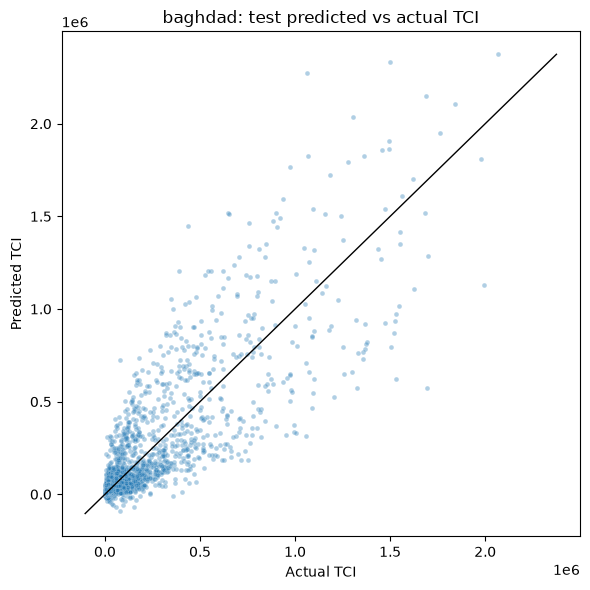

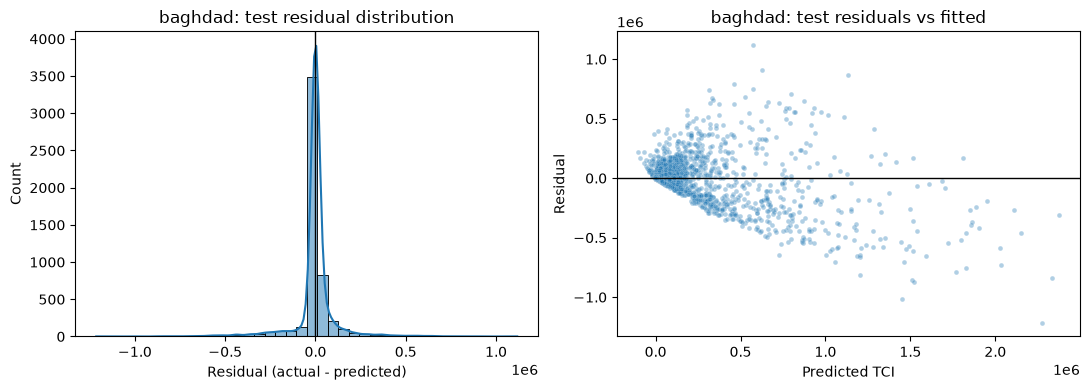

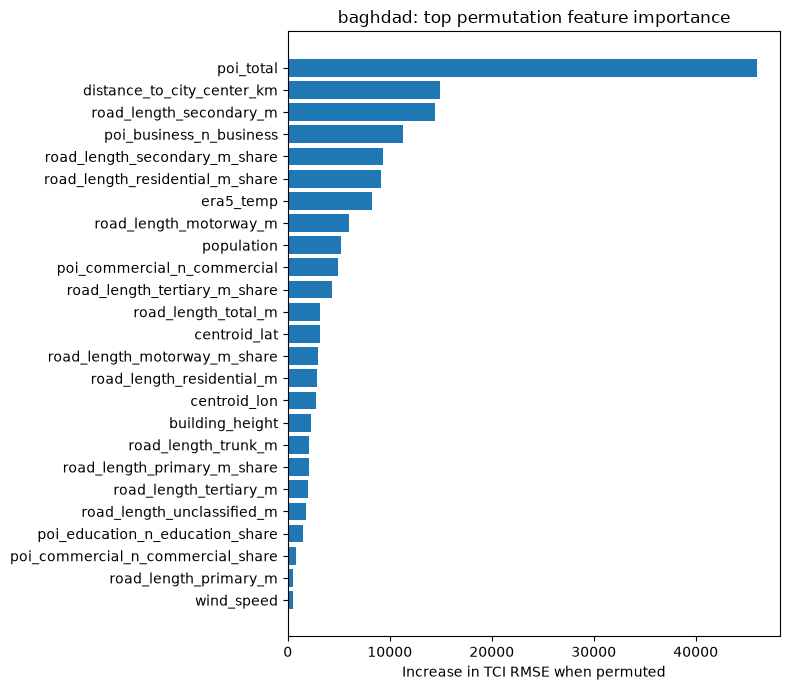

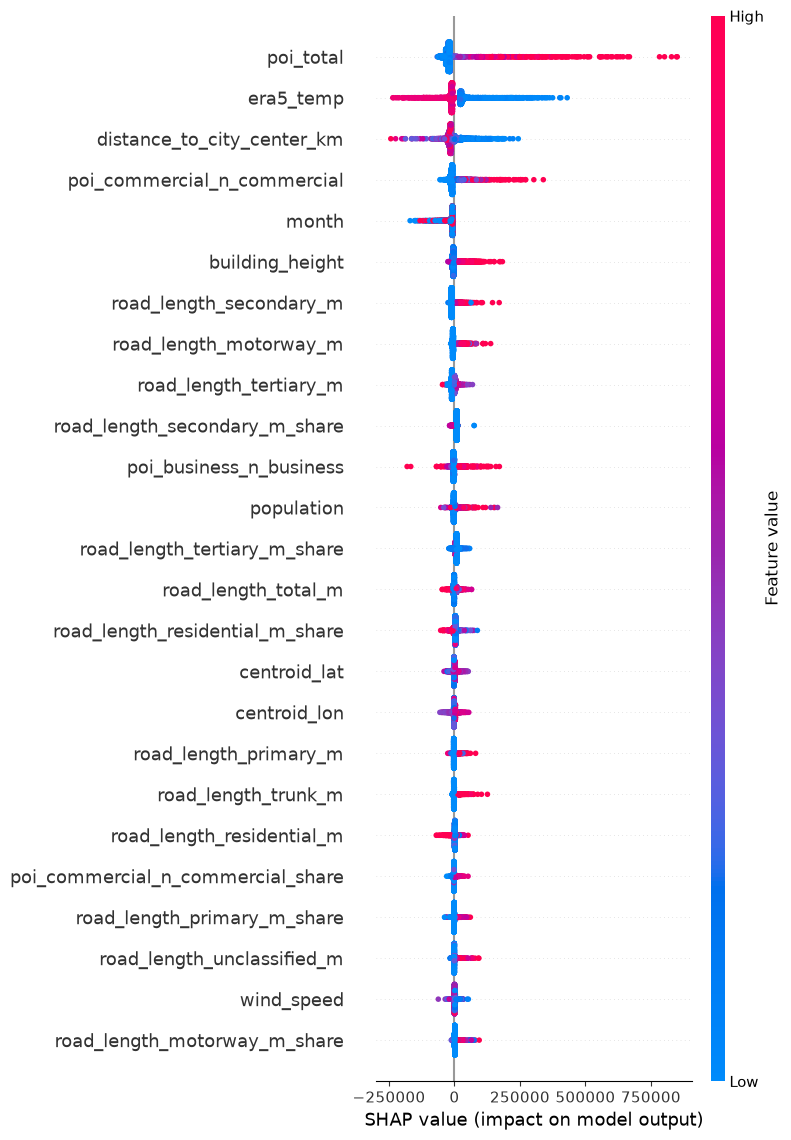

Saved directional SHAP outputs: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/baghdad/shap_feature_importance.csv NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/baghdad/shap_summary_top25_directional.png


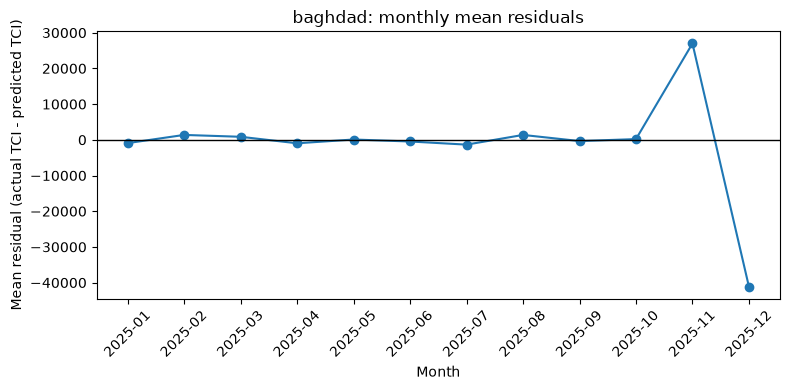

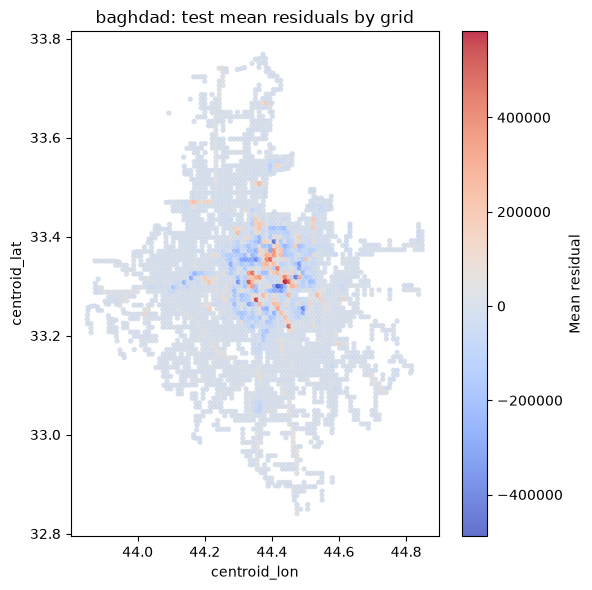


Final test evaluation:
Selected model: hist_gradient_boosting
Selection reason: lowest temporal-CV mean RMSE = 75261.0516
Worst temporal-CV fold RMSE = 126141.8722
Development TCI RMSE=45735.6206, MAE=19240.1567, R2=0.9713
Test TCI RMSE=119218.8336, MAE=48654.9742, R2=0.6998
Saved outputs to: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/baghdad

===== TEMPORAL CV MODEL | raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month | BUENOS_AIRES =====
Target: raw TCI
Range: full range
rows: before_dropna=38,323, after_dropna=36,522, development=30,719, test=5,803
elastic_net: testing 15 parameter settings with temporal CV
random_forest: testing 15 parameter settings with temporal CV
hist_gradient_boosting: testing 15 parameter settings with temporal CV
xgboost: testing 15 parameter settings with temporal CV

Best candidate per model, ranked by temporal-CV mean RMSE:
     

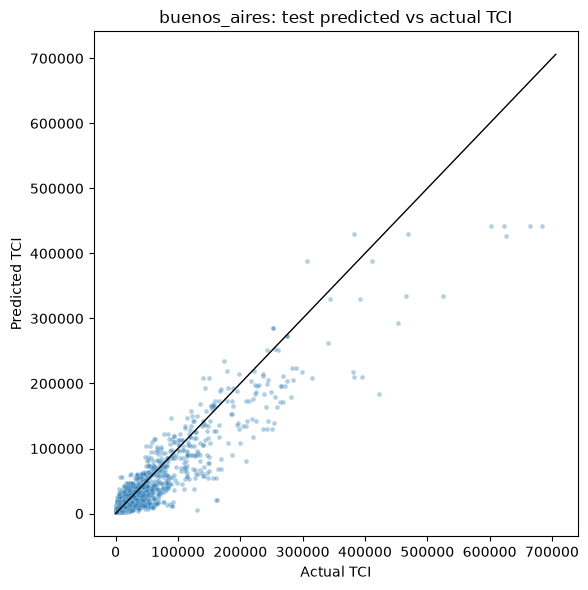

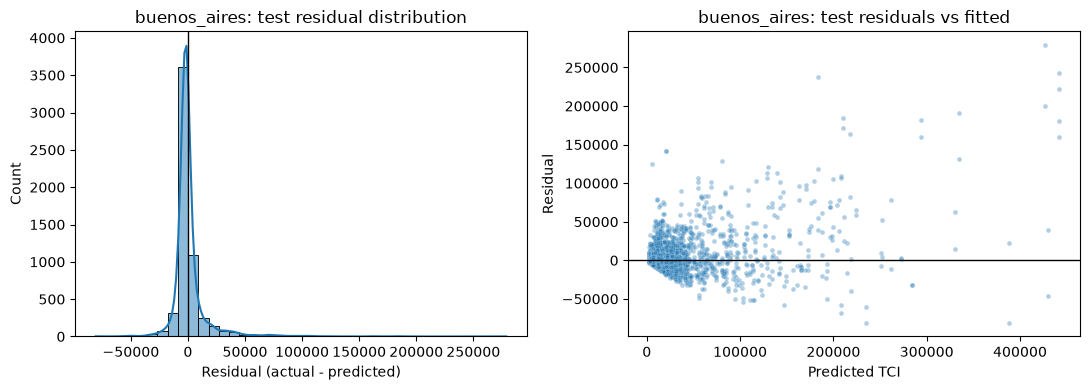

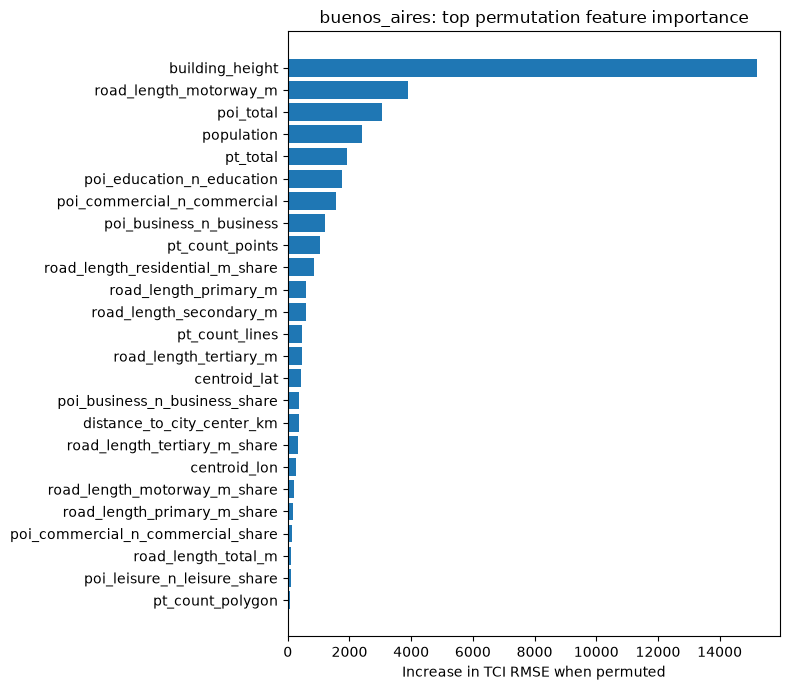

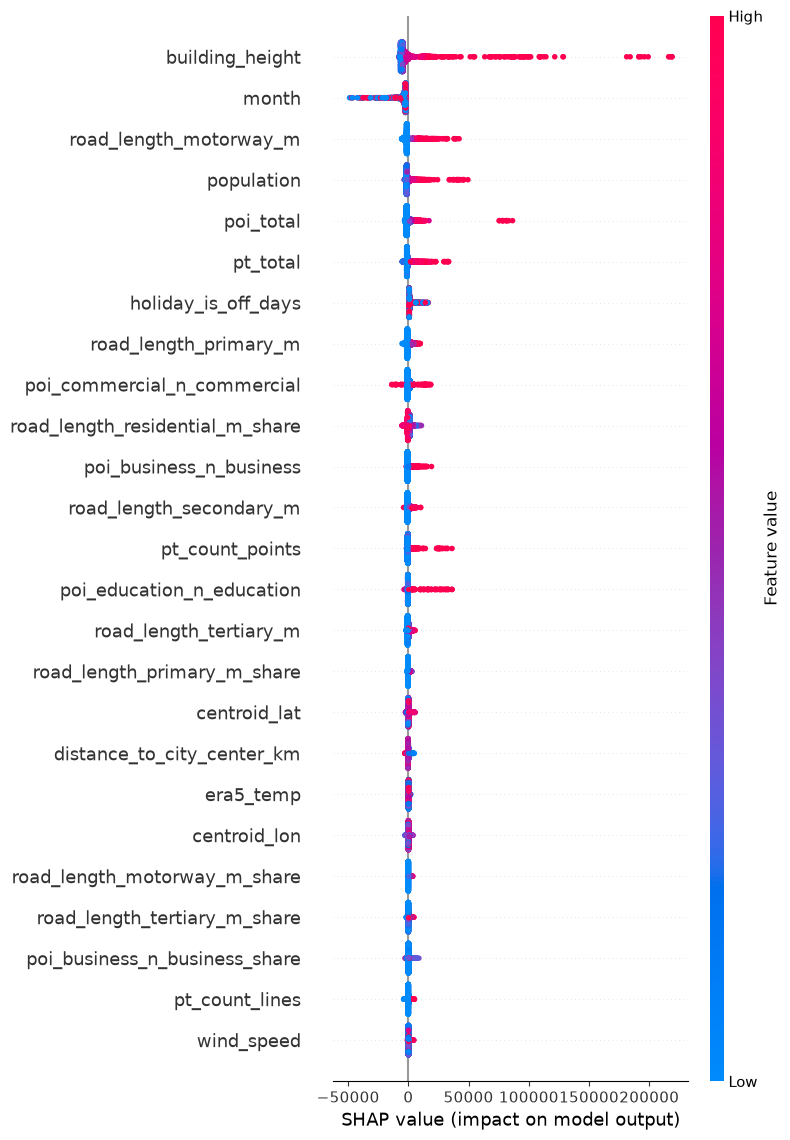

Saved directional SHAP outputs: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/buenos_aires/shap_feature_importance.csv NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/buenos_aires/shap_summary_top25_directional.png


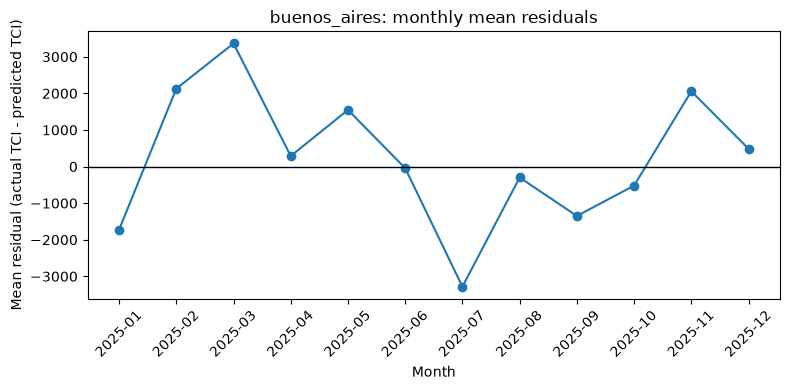

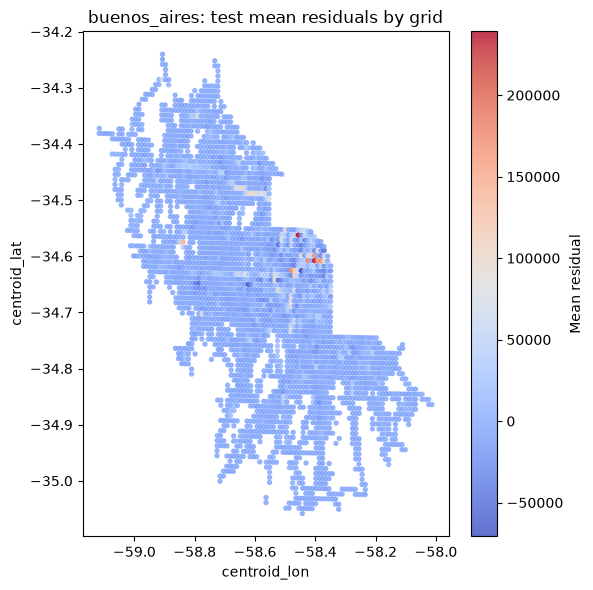


Final test evaluation:
Selected model: hist_gradient_boosting
Selection reason: lowest temporal-CV mean RMSE = 21796.5027
Worst temporal-CV fold RMSE = 41020.9562
Development TCI RMSE=21244.6279, MAE=7764.3409, R2=0.8230
Test TCI RMSE=17341.0908, MAE=7535.7405, R2=0.8568
Saved outputs to: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/buenos_aires

===== TEMPORAL CV MODEL | raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month | CAIRO =====
Target: raw TCI
Range: full range
rows: before_dropna=25,959, after_dropna=25,959, development=21,940, test=4,019
elastic_net: testing 15 parameter settings with temporal CV
random_forest: testing 15 parameter settings with temporal CV
hist_gradient_boosting: testing 15 parameter settings with temporal CV
xgboost: testing 15 parameter settings with temporal CV

Best candidate per model, ranked by temporal-CV mean RMSE:
           

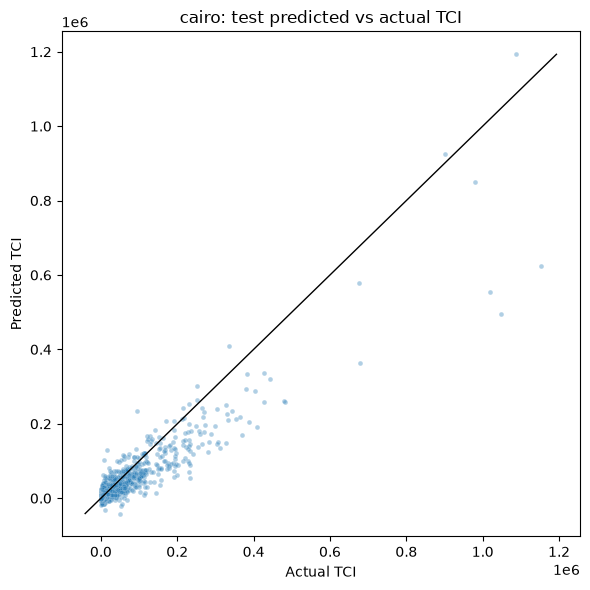

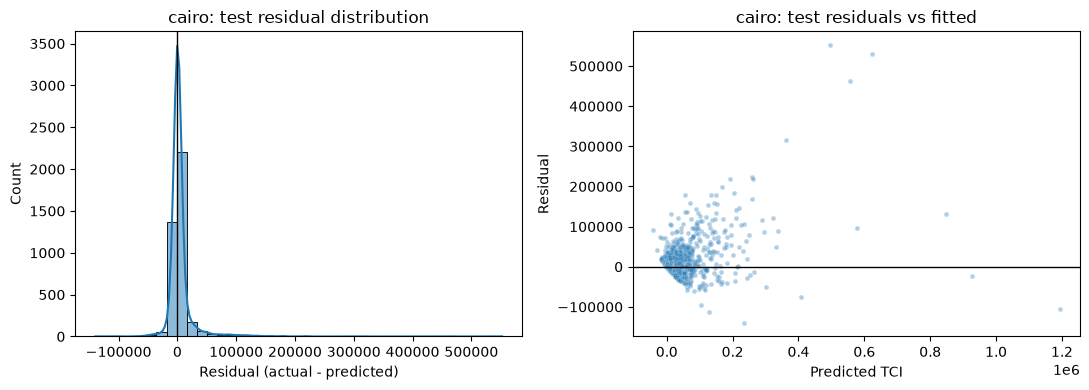

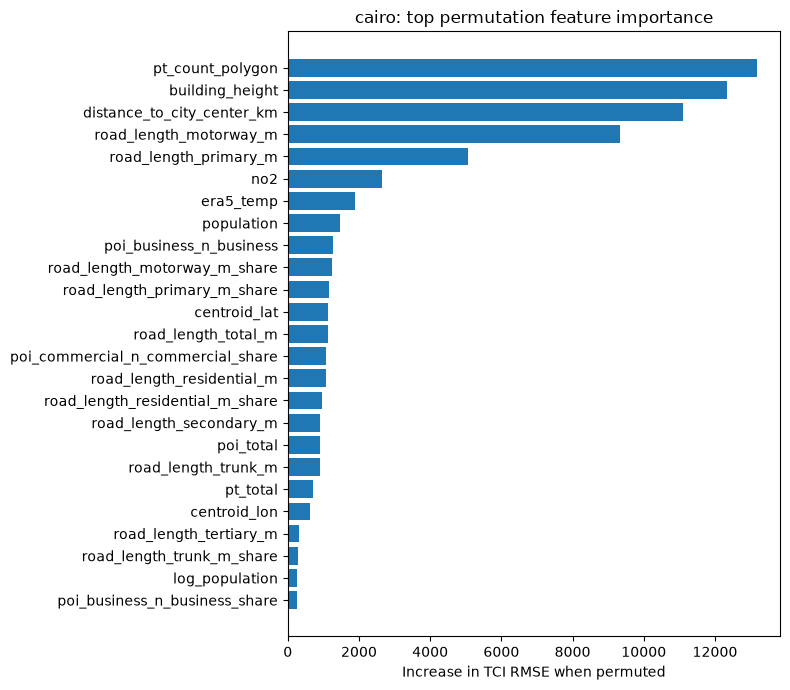

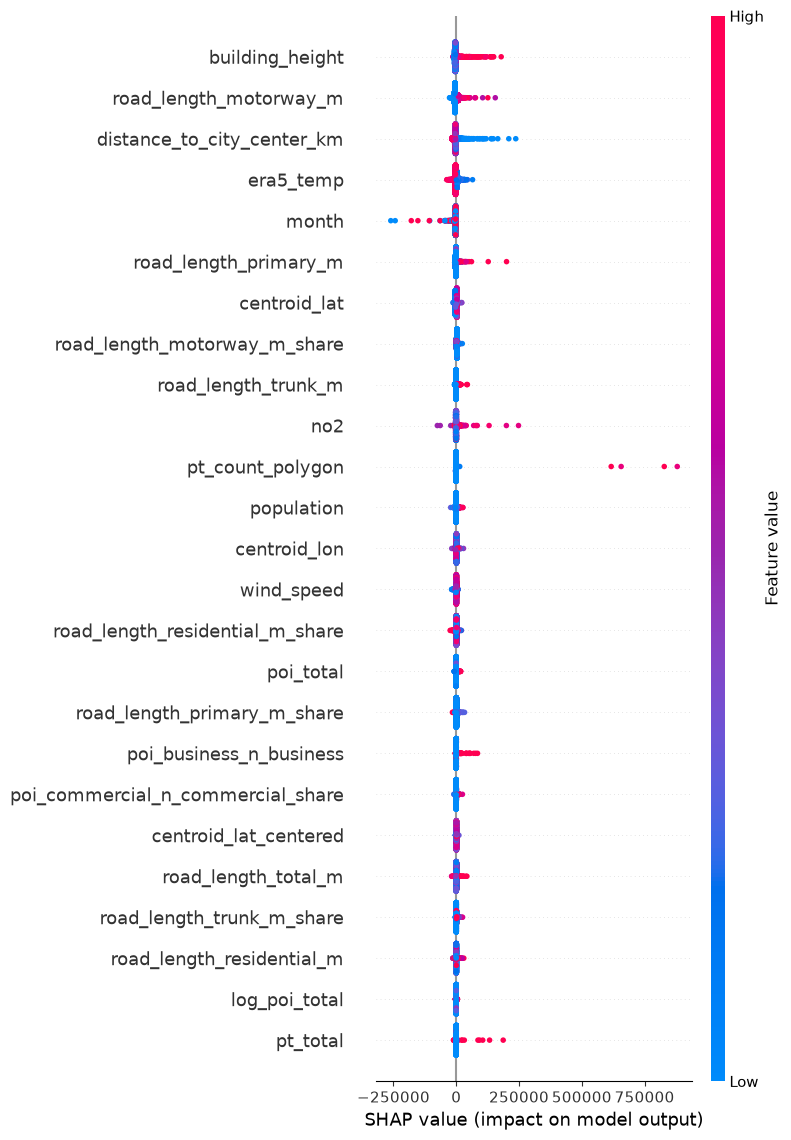

Saved directional SHAP outputs: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/cairo/shap_feature_importance.csv NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/cairo/shap_summary_top25_directional.png


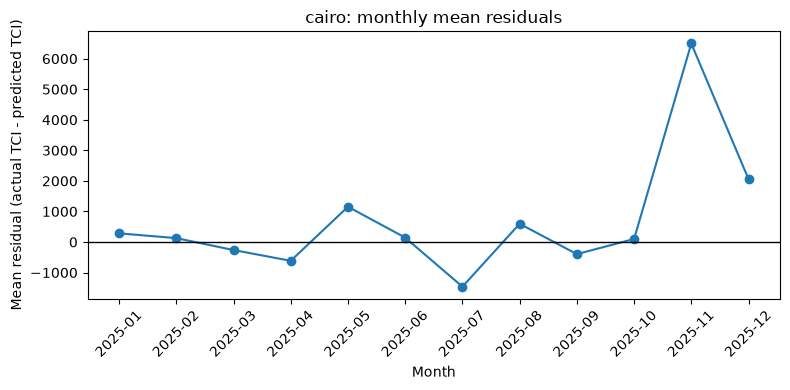

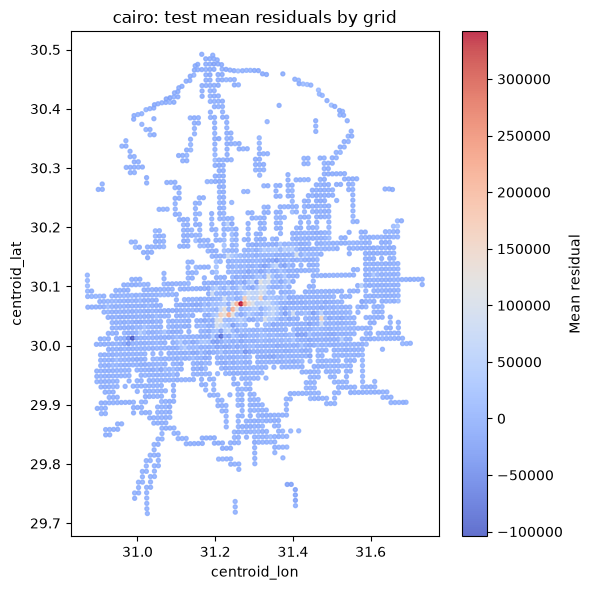


Final test evaluation:
Selected model: xgboost
Selection reason: lowest temporal-CV mean RMSE = 22910.5257
Worst temporal-CV fold RMSE = 41717.3846
Development TCI RMSE=14314.4334, MAE=6535.8595, R2=0.9598
Test TCI RMSE=25770.0476, MAE=9541.7242, R2=0.8217
Saved outputs to: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/cairo

===== TEMPORAL CV MODEL | raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month | DAKAR =====
Target: raw TCI
Range: full range
rows: before_dropna=3,681, after_dropna=3,681, development=3,176, test=505
elastic_net: testing 15 parameter settings with temporal CV
random_forest: testing 15 parameter settings with temporal CV
hist_gradient_boosting: testing 15 parameter settings with temporal CV
xgboost: testing 15 parameter settings with temporal CV

Best candidate per model, ranked by temporal-CV mean RMSE:
            model_name  candidate_id  

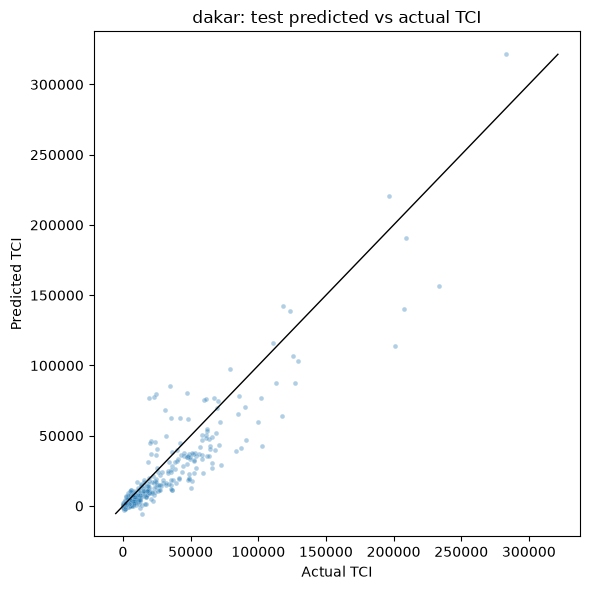

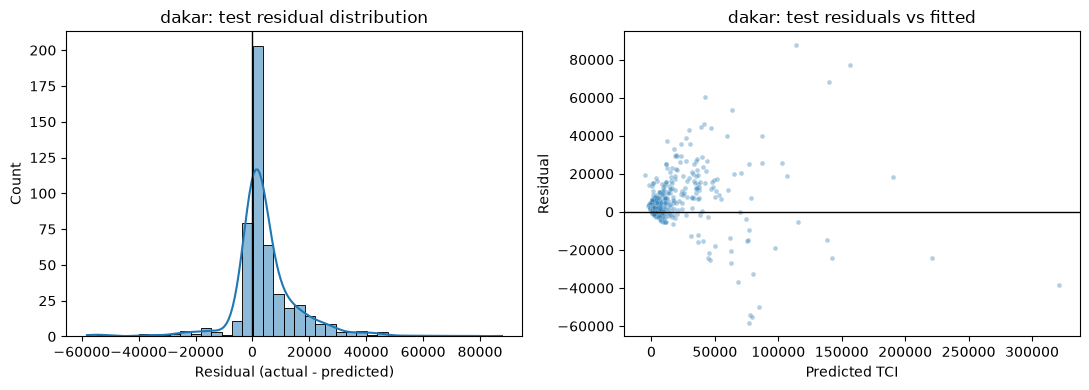

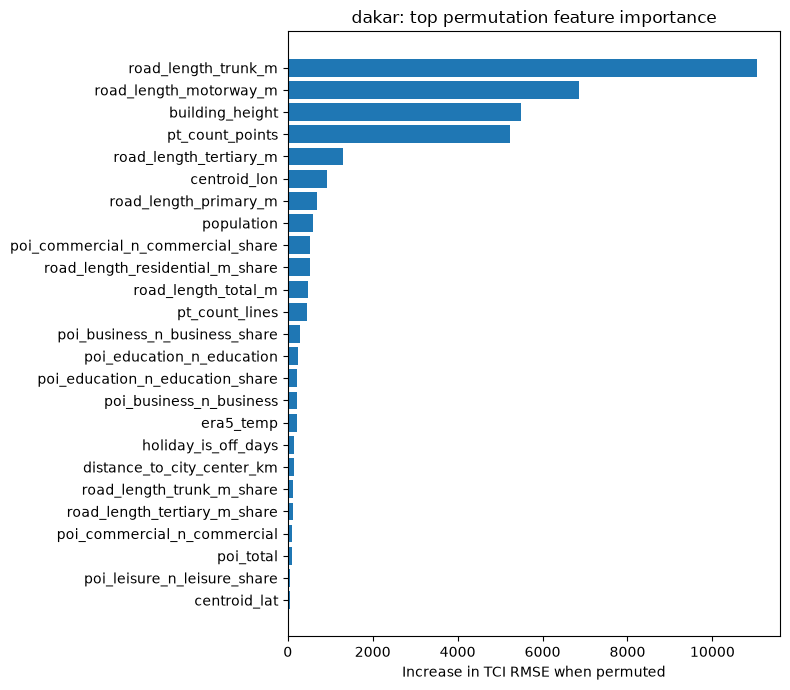

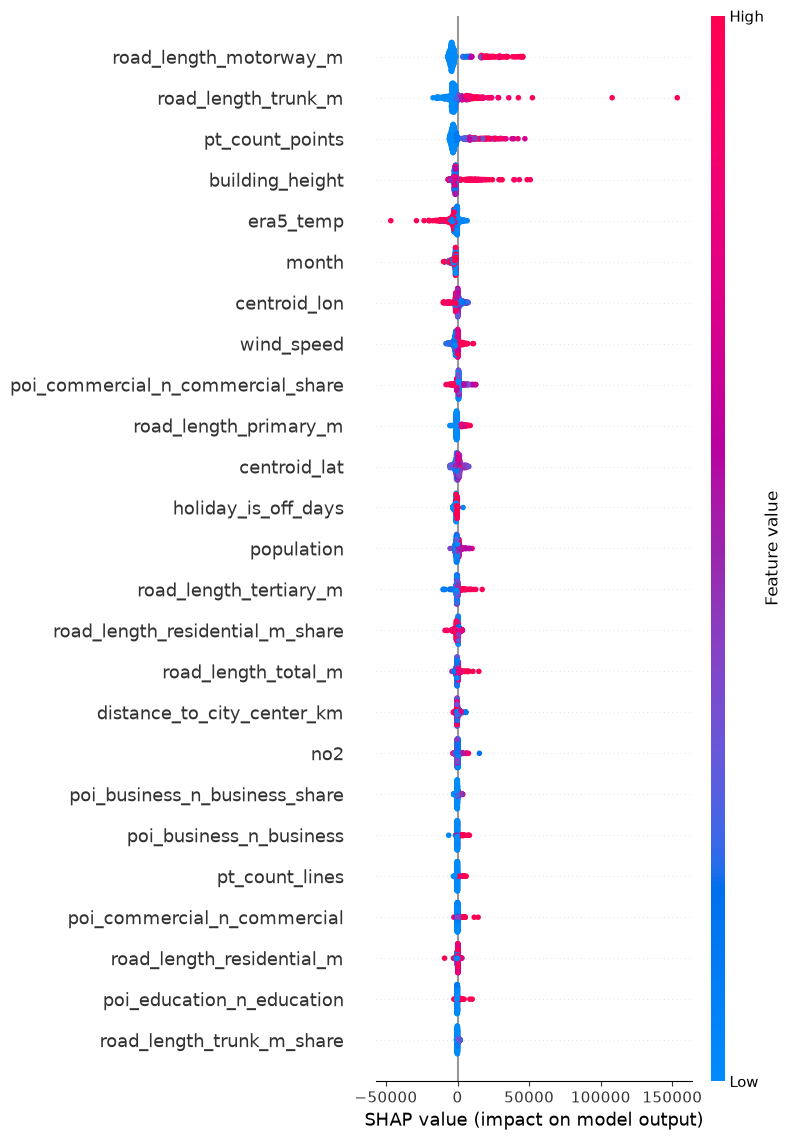

Saved directional SHAP outputs: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/dakar/shap_feature_importance.csv NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/dakar/shap_summary_top25_directional.png


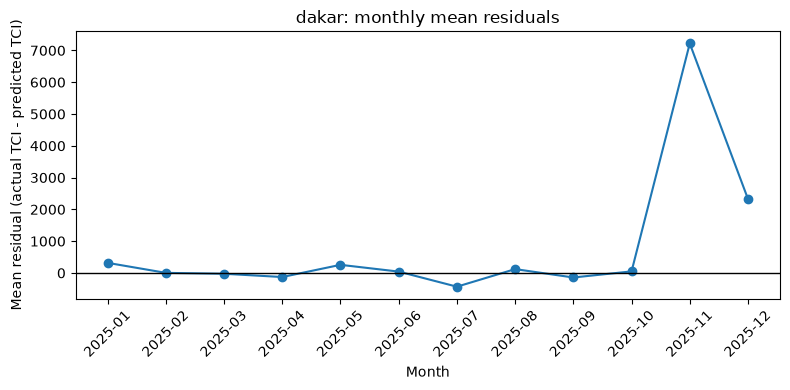

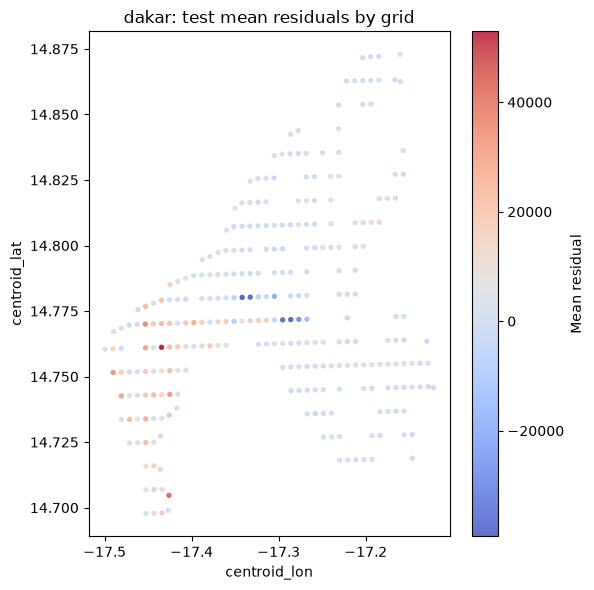


Final test evaluation:
Selected model: xgboost
Selection reason: lowest temporal-CV mean RMSE = 11457.9237
Worst temporal-CV fold RMSE = 22140.3087
Development TCI RMSE=4525.6893, MAE=2636.8228, R2=0.9863
Test TCI RMSE=13992.2045, MAE=7761.8783, R2=0.8219
Saved outputs to: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/dakar

===== TEMPORAL CV MODEL | raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month | LIMA =====
Target: raw TCI
Range: full range
rows: before_dropna=10,732, after_dropna=10,732, development=8,846, test=1,886
elastic_net: testing 15 parameter settings with temporal CV
random_forest: testing 15 parameter settings with temporal CV
hist_gradient_boosting: testing 15 parameter settings with temporal CV
xgboost: testing 15 parameter settings with temporal CV

Best candidate per model, ranked by temporal-CV mean RMSE:
            model_name  candidate_id

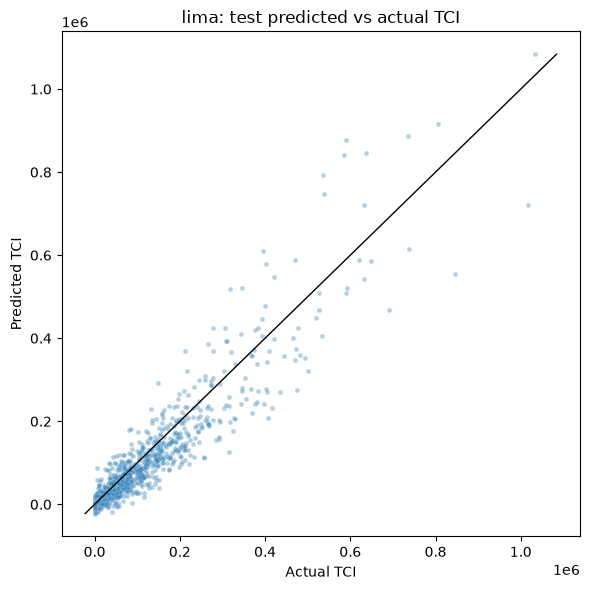

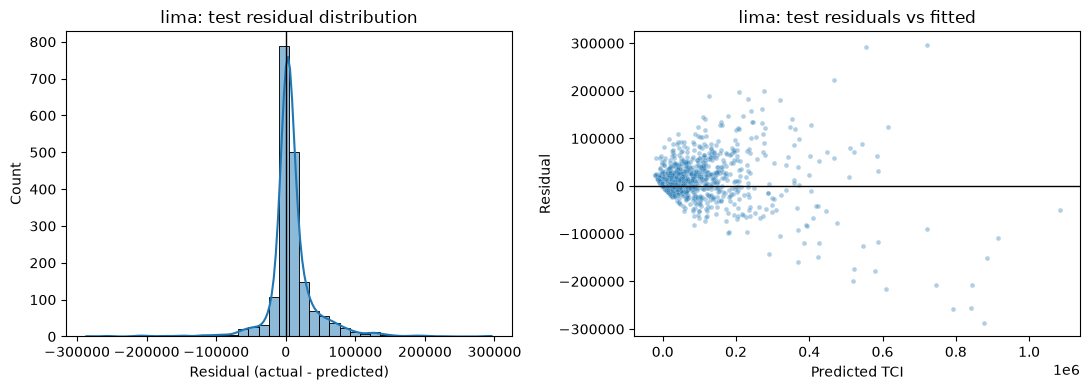

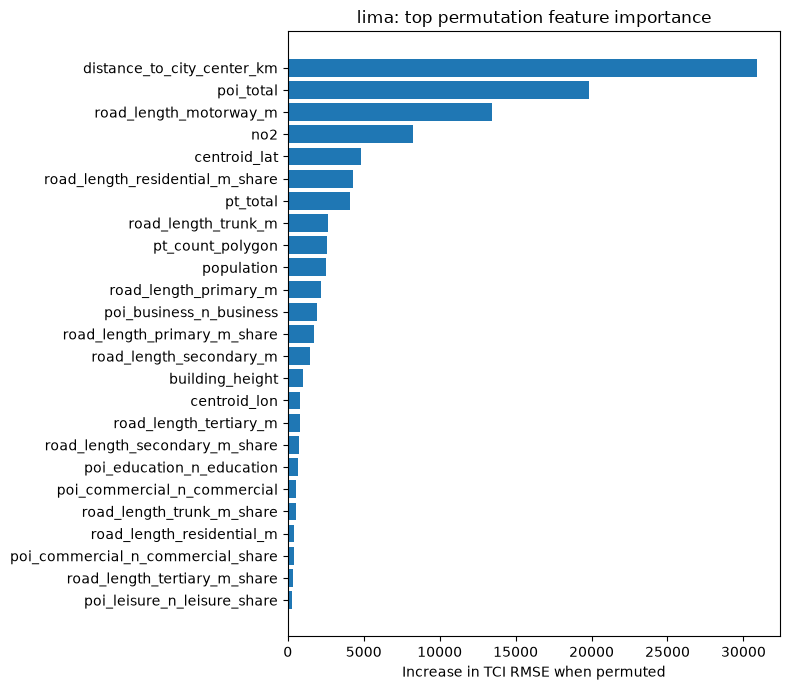

Directional SHAP summary was skipped for lima (xgboost) because SHAP could not explain this model: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. Consider retrying with the feature_perturbation='interventional' option. This check failed because for one of the samples the sum of the SHAP values was 793686.062500, while the model output was 793684.937500. If this difference is acceptable you can set check_additivity=False to disable this check.


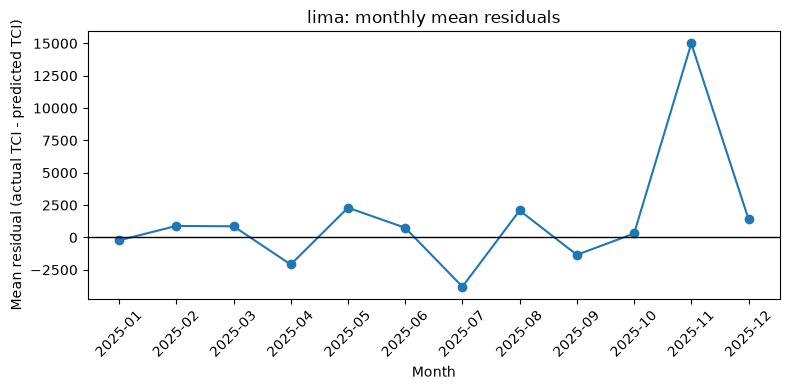

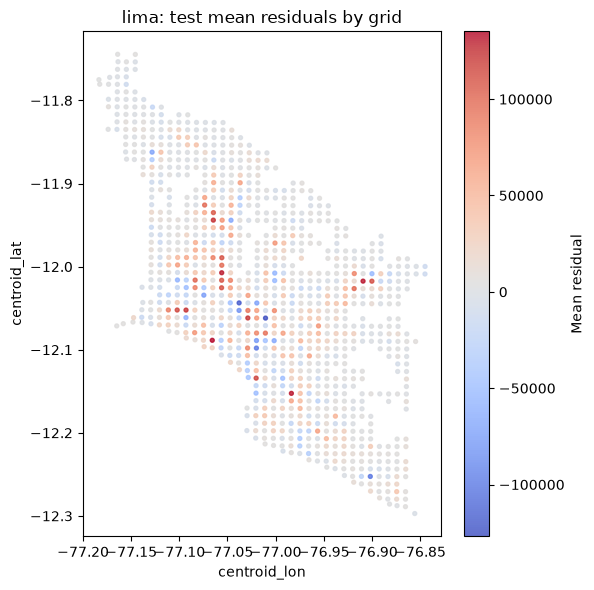


Final test evaluation:
Selected model: xgboost
Selection reason: lowest temporal-CV mean RMSE = 64084.1704
Worst temporal-CV fold RMSE = 124329.1332
Development TCI RMSE=27854.9744, MAE=15221.2112, R2=0.9718
Test TCI RMSE=37630.3432, MAE=19592.1053, R2=0.8822
Saved outputs to: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/lima

===== TEMPORAL CV MODEL | raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month | MEXICO_CITY =====
Target: raw TCI
Range: full range
rows: before_dropna=41,319, after_dropna=41,319, development=34,775, test=6,544
elastic_net: testing 15 parameter settings with temporal CV
random_forest: testing 15 parameter settings with temporal CV
hist_gradient_boosting: testing 15 parameter settings with temporal CV
xgboost: testing 15 parameter settings with temporal CV

Best candidate per model, ranked by temporal-CV mean RMSE:
            model_name  c

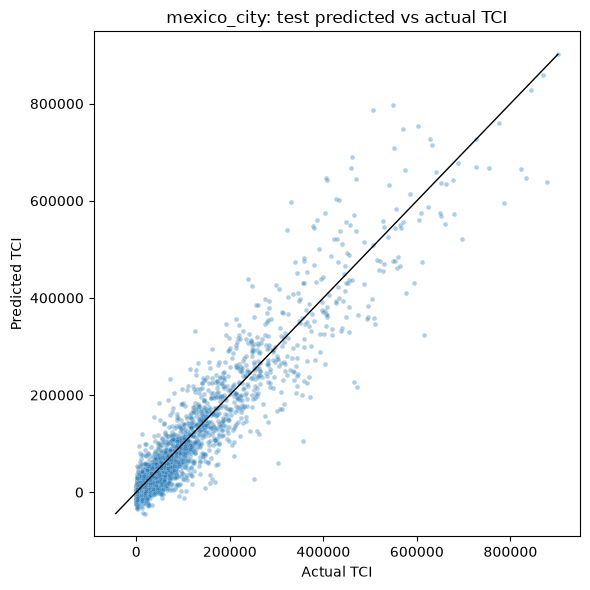

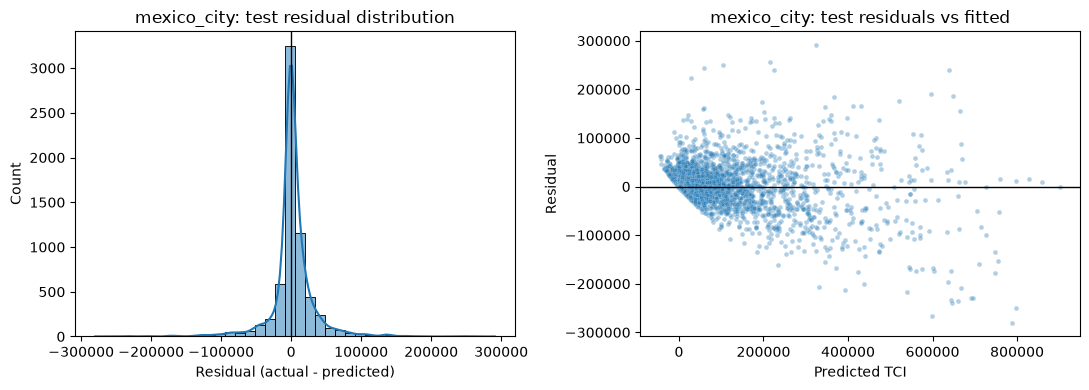

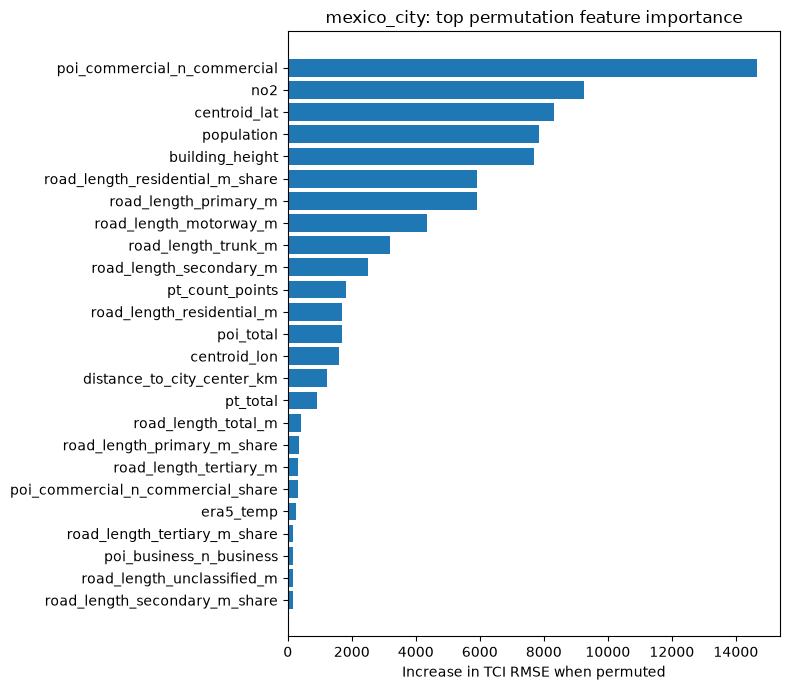

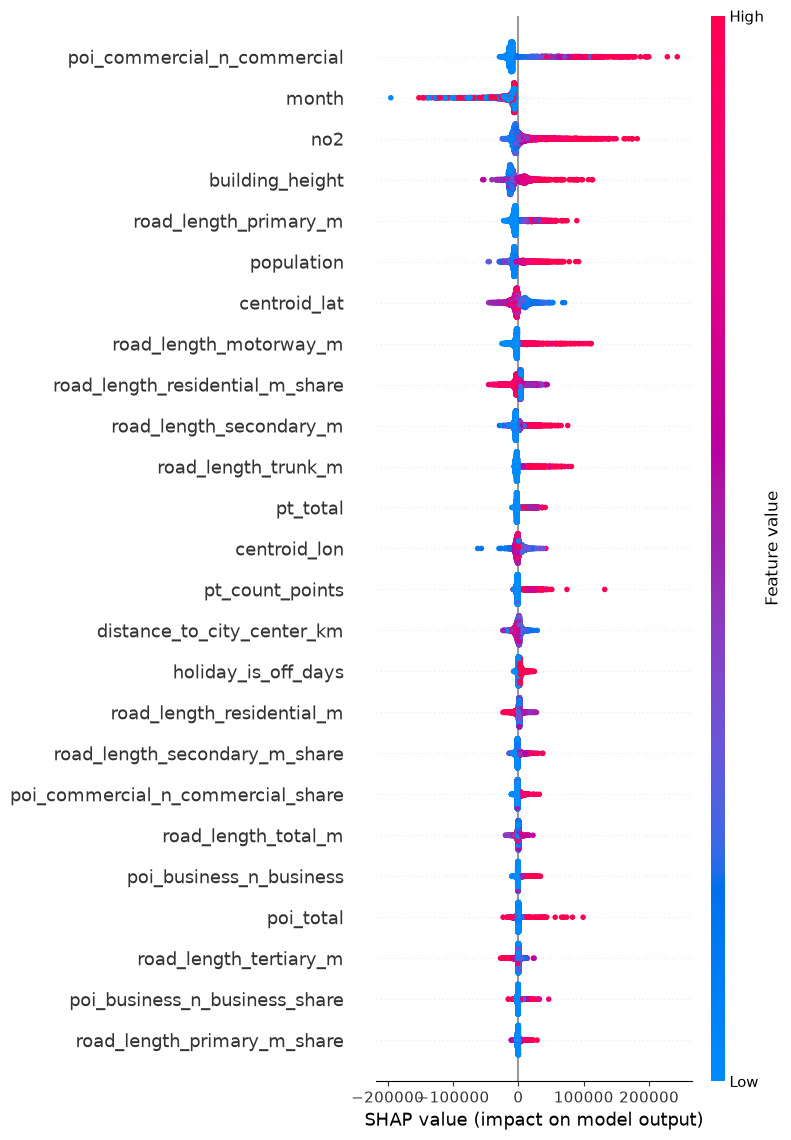

Saved directional SHAP outputs: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/mexico_city/shap_feature_importance.csv NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/mexico_city/shap_summary_top25_directional.png


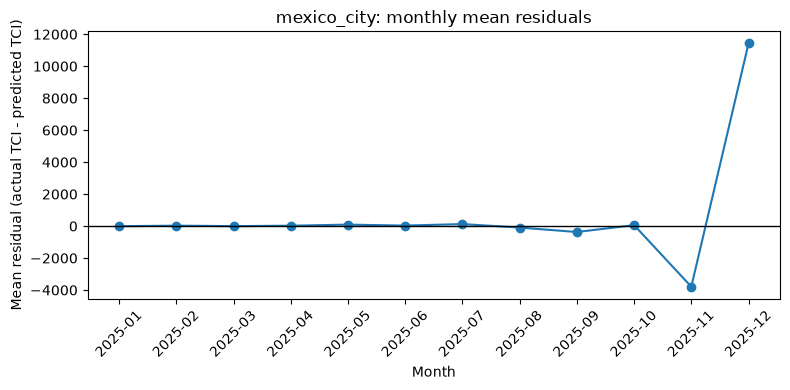

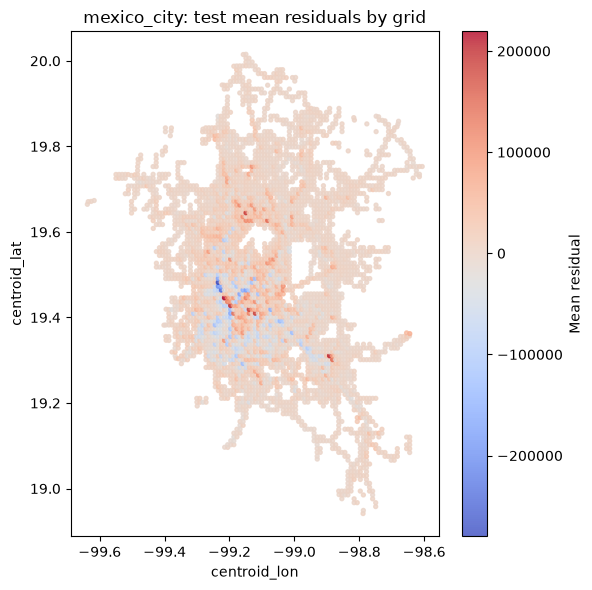


Final test evaluation:
Selected model: xgboost
Selection reason: lowest temporal-CV mean RMSE = 48020.1070
Worst temporal-CV fold RMSE = 85090.0670
Development TCI RMSE=12012.0352, MAE=7159.2014, R2=0.9906
Test TCI RMSE=32532.2016, MAE=17241.2345, R2=0.9018
Saved outputs to: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/mexico_city

===== TEMPORAL CV MODEL | raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month | MUMBAI =====
Target: raw TCI
Range: full range
rows: before_dropna=3,108, after_dropna=3,108, development=2,408, test=700
elastic_net: testing 15 parameter settings with temporal CV
random_forest: testing 15 parameter settings with temporal CV
hist_gradient_boosting: testing 15 parameter settings with temporal CV
xgboost: testing 15 parameter settings with temporal CV

Best candidate per model, ranked by temporal-CV mean RMSE:
            model_name  candid

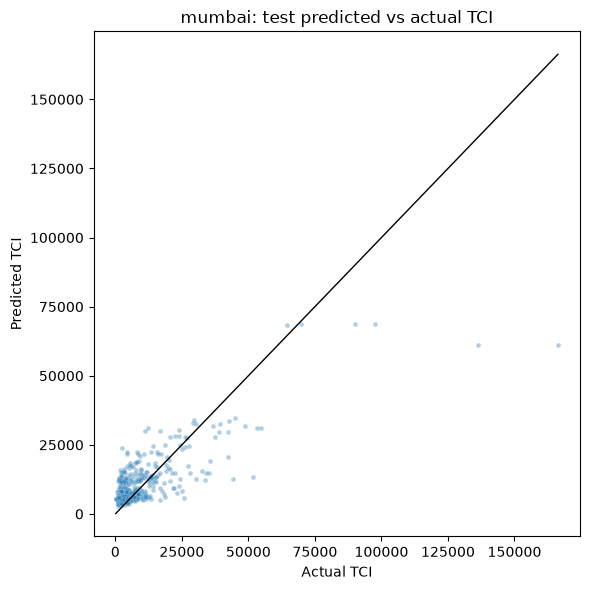

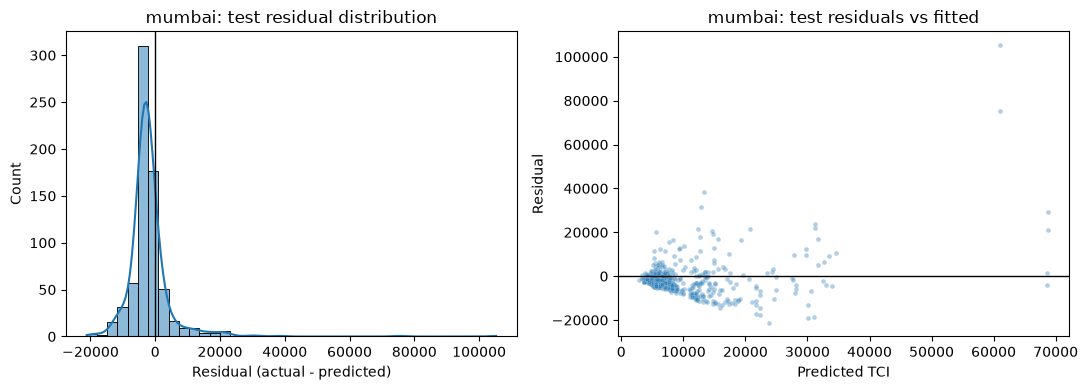

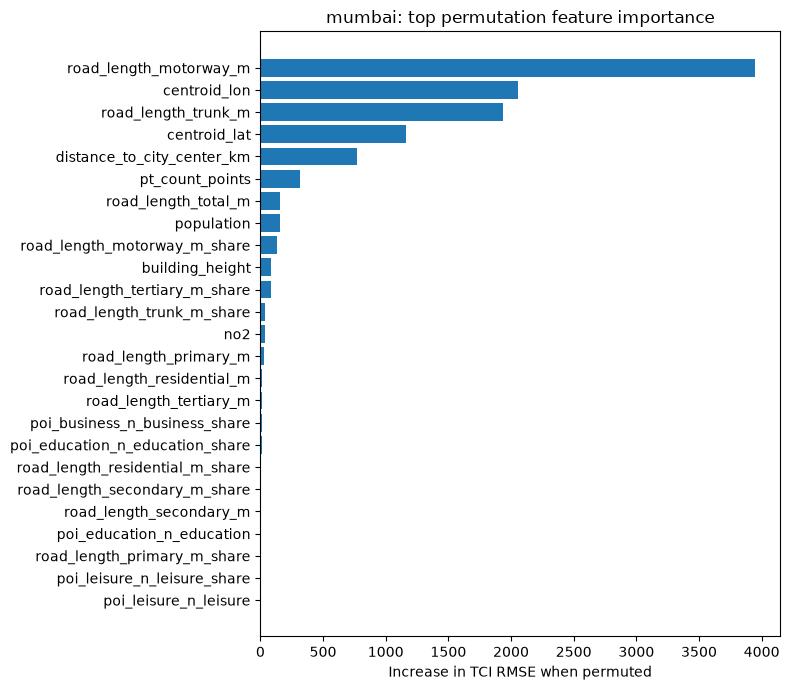

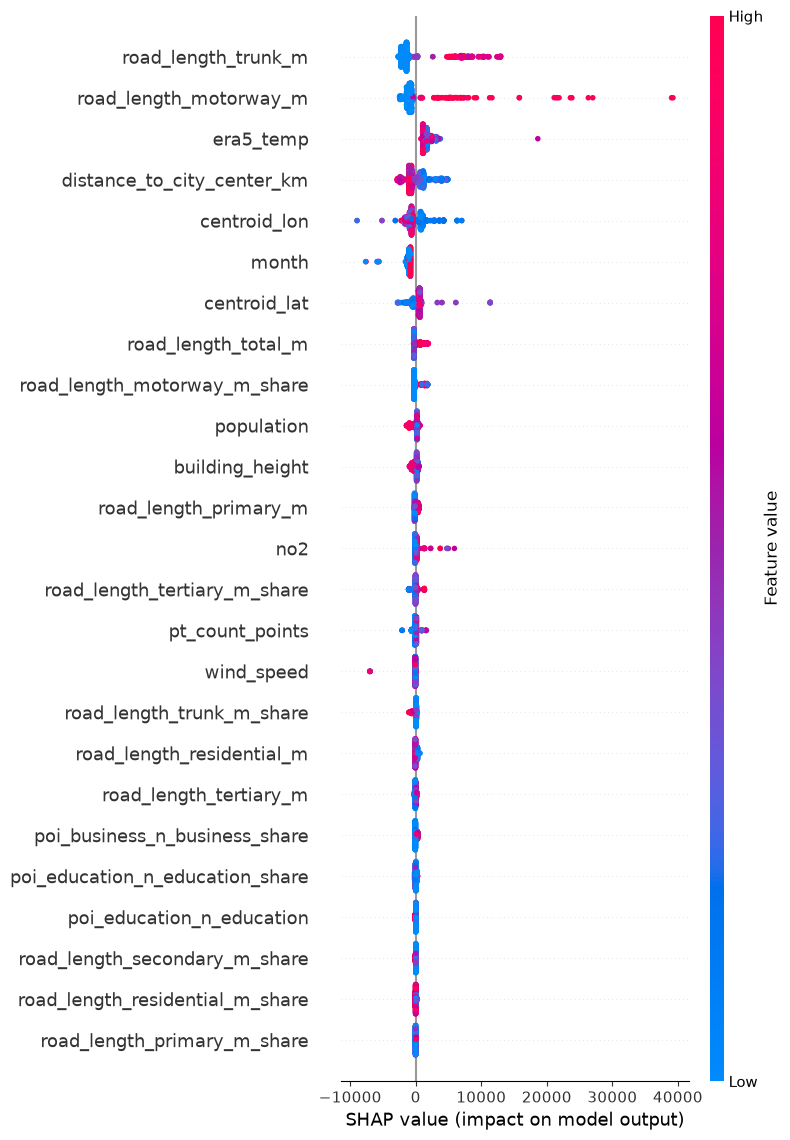

Saved directional SHAP outputs: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/mumbai/shap_feature_importance.csv NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/mumbai/shap_summary_top25_directional.png


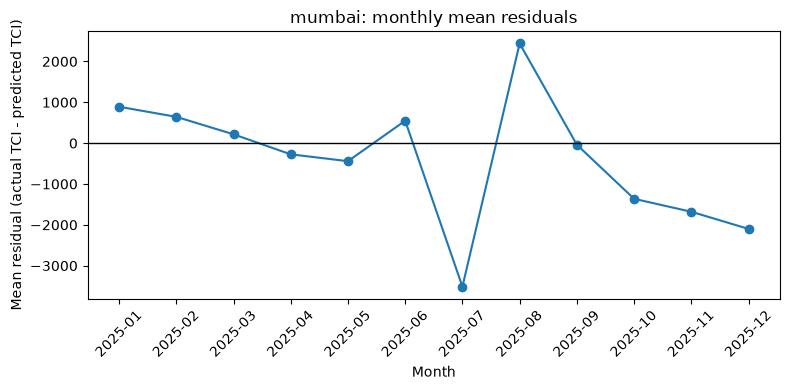

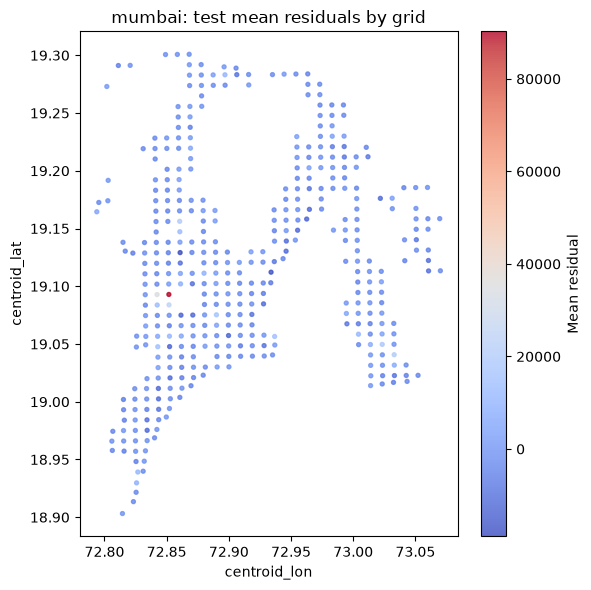


Final test evaluation:
Selected model: xgboost
Selection reason: lowest temporal-CV mean RMSE = 5690.3341
Worst temporal-CV fold RMSE = 7236.4270
Development TCI RMSE=6898.2885, MAE=3672.2554, R2=0.7381
Test TCI RMSE=7803.0985, MAE=4612.6276, R2=0.6057
Saved outputs to: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/mumbai

===== TEMPORAL CV MODEL | raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month | NEW_YORK =====
Target: raw TCI
Range: full range
rows: before_dropna=9,467, after_dropna=8,846, development=7,378, test=1,468
elastic_net: testing 15 parameter settings with temporal CV
random_forest: testing 15 parameter settings with temporal CV
hist_gradient_boosting: testing 15 parameter settings with temporal CV
xgboost: testing 15 parameter settings with temporal CV

Best candidate per model, ranked by temporal-CV mean RMSE:
            model_name  candidate_id

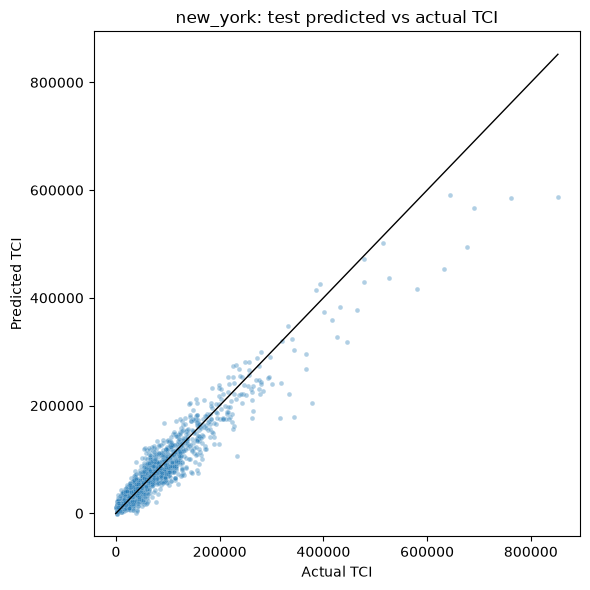

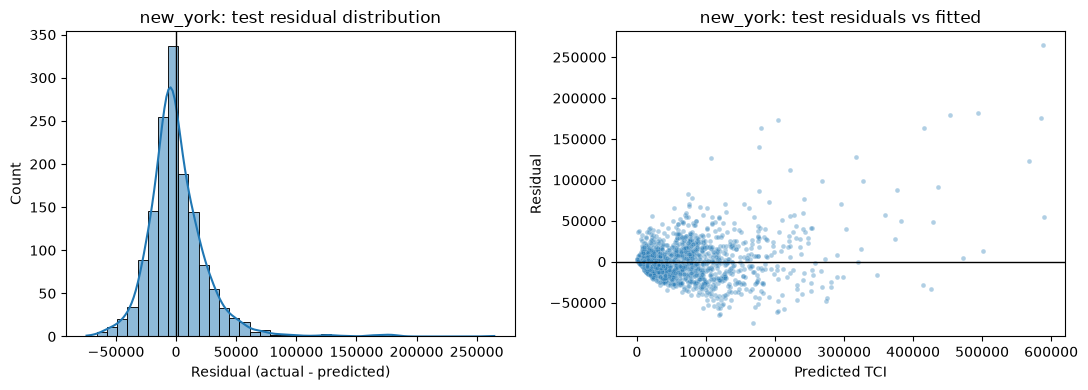

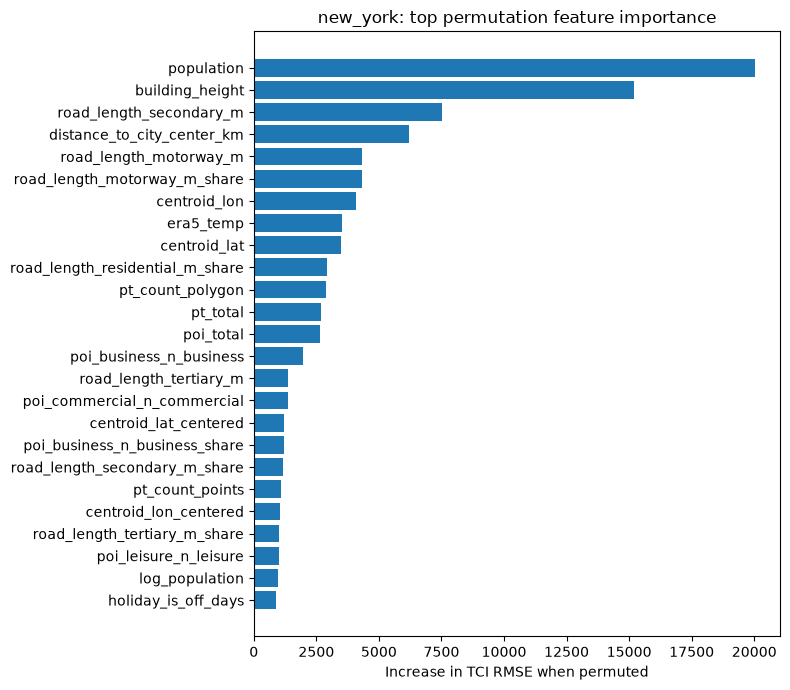

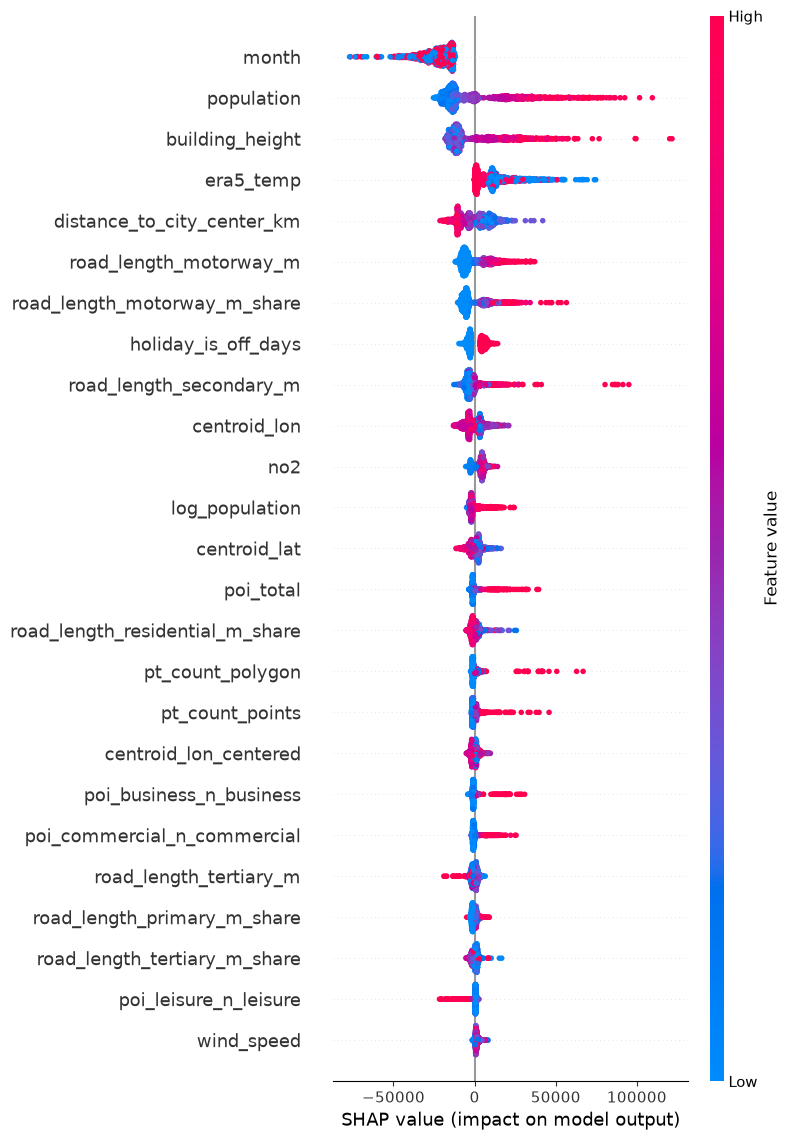

Saved directional SHAP outputs: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/new_york/shap_feature_importance.csv NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/new_york/shap_summary_top25_directional.png


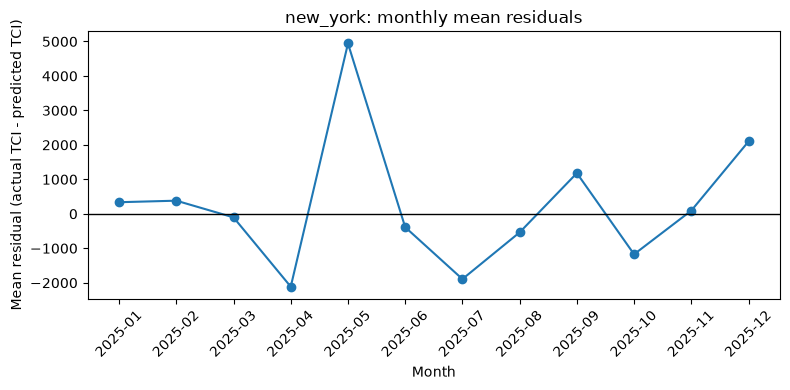

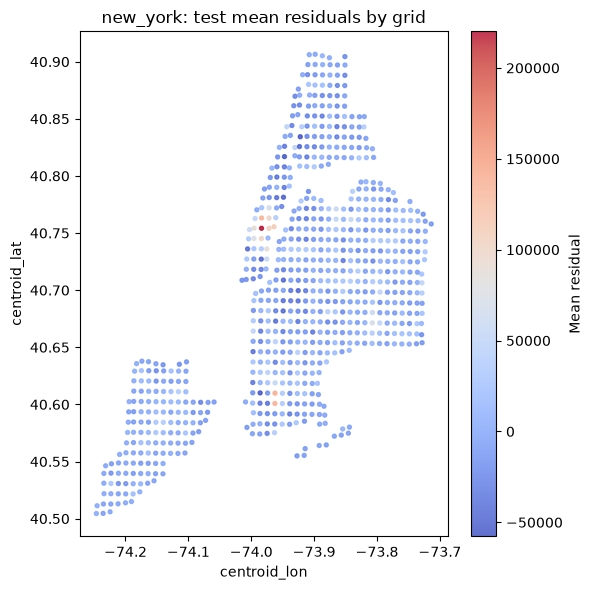


Final test evaluation:
Selected model: xgboost
Selection reason: lowest temporal-CV mean RMSE = 38435.3338
Worst temporal-CV fold RMSE = 63197.2364
Development TCI RMSE=22634.4324, MAE=15154.2578, R2=0.9483
Test TCI RMSE=26342.6525, MAE=17249.5720, R2=0.9044
Saved outputs to: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/new_york


In [7]:
SCENARIO_OUTPUT_ROOT = OUTPUT_ROOT / SCENARIO_ID
SCENARIO_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

main_model_results = {}
main_model_metrics = []
main_model_search_results = []
main_model_feature_importance = []
main_model_diagnostics = []
main_model_artifacts = {}


def get_fold_frames(model_panel: pd.DataFrame, fold: dict) -> tuple[pd.DataFrame, pd.DataFrame]:
    train_df = model_panel.loc[model_panel[MONTH_COL].isin(fold["train_months"])].copy()
    valid_df = model_panel.loc[model_panel[MONTH_COL].eq(fold["validation_month"])].copy()
    return train_df, valid_df


def summarize_candidate_fold_metrics(fold_metric_rows: list[dict]) -> dict:
    fold_df = pd.DataFrame(fold_metric_rows)
    return {
        "folds_used": int(len(fold_df)),
        "cv_mean_rmse": fold_df["validation_rmse"].mean(),
        "cv_median_rmse": fold_df["validation_rmse"].median(),
        "cv_worst_rmse": fold_df["validation_rmse"].max(),
        "cv_rmse_std": fold_df["validation_rmse"].std(ddof=0),
        "cv_mean_mae": fold_df["validation_mae"].mean(),
        "cv_mean_r2": fold_df["validation_r2"].mean(),
        "cv_min_r2": fold_df["validation_r2"].min(),
        "mean_train_rmse": fold_df["train_rmse"].mean(),
        "mean_train_r2": fold_df["train_r2"].mean(),
    }


def train_model_for_city(city: str, panel: pd.DataFrame, feature_cols: list[str], output_dir: Path) -> dict:
    model_panel, prep_metadata = prepare_model_panel(panel, feature_cols)

    development_df = model_panel.loc[model_panel["split"].eq("development")].copy()
    test_df = model_panel.loc[model_panel["split"].eq("test")].copy()

    if development_df.empty or test_df.empty:
        raise ValueError(
            f"{city}: development or test split is empty after filtering. "
            f"development={len(development_df)}, test={len(test_df)}"
        )

    X_development = development_df[feature_cols]
    y_development = development_df[TARGET_COL]
    X_test = test_df[feature_cols]
    y_test = test_df[TARGET_COL]

    output_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n===== TEMPORAL CV MODEL | {SCENARIO_ID} | {city.upper()} =====")
    print("Target: raw TCI")
    print("Range: full range")
    print(
        f"rows: before_dropna={prep_metadata['rows_before_dropna']:,}, "
        f"after_dropna={prep_metadata['rows_after_dropna']:,}, "
        f"development={len(development_df):,}, test={len(test_df):,}"
    )

    candidate_rows = []
    fold_rows = []

    for model_name in MODEL_PARAM_SPACES:
        sampled_params = sample_params(model_name, N_ITER_PER_MODEL)
        print(f"{model_name}: testing {len(sampled_params)} parameter settings with temporal CV")

        for candidate_id, params in enumerate(sampled_params, start=1):
            candidate_fold_rows = []

            for fold in TEMPORAL_CV_FOLDS:
                fold_train_df, fold_valid_df = get_fold_frames(model_panel, fold)
                if fold_train_df.empty or fold_valid_df.empty:
                    print(
                        f"Warning: {city} {model_name} candidate {candidate_id} "
                        f"skips {fold['fold_id']} because train or validation rows are empty."
                    )
                    continue

                model = build_model(model_name, params)
                X_fold_train = fold_train_df[feature_cols]
                y_fold_train = fold_train_df[TARGET_COL]
                X_fold_valid = fold_valid_df[feature_cols]
                y_fold_valid = fold_valid_df[TARGET_COL]

                model.fit(X_fold_train, y_fold_train)
                train_metrics = evaluate_model(model, X_fold_train, y_fold_train)
                valid_metrics = evaluate_model(model, X_fold_valid, y_fold_valid)

                fold_row = {
                    "city": city,
                    "scenario_id": SCENARIO_ID,
                    "target_col": TARGET_COL,
                    "target_transform": "none_raw_tci",
                    "range_mode": "full_range",
                    "model_name": model_name,
                    "candidate_id": candidate_id,
                    "params": json.dumps(params, sort_keys=True),
                    "fold_id": fold["fold_id"],
                    "fold_train_months": ",".join(map(str, fold["train_months"])),
                    "fold_validation_month": fold["validation_month"],
                    "fold_train_rows": len(fold_train_df),
                    "fold_validation_rows": len(fold_valid_df),
                    "train_rmse": train_metrics["rmse"],
                    "train_mae": train_metrics["mae"],
                    "train_r2": train_metrics["r2"],
                    "validation_rmse": valid_metrics["rmse"],
                    "validation_mae": valid_metrics["mae"],
                    "validation_r2": valid_metrics["r2"],
                }
                candidate_fold_rows.append(fold_row)
                fold_rows.append(fold_row)

            if not candidate_fold_rows:
                continue

            summary = summarize_candidate_fold_metrics(candidate_fold_rows)
            candidate_rows.append({
                "city": city,
                "scenario_id": SCENARIO_ID,
                "target_col": TARGET_COL,
                "target_transform": "none_raw_tci",
                "range_mode": "full_range",
                "model_name": model_name,
                "candidate_id": candidate_id,
                "params": json.dumps(params, sort_keys=True),
                "feature_count": len(feature_cols),
                **summary,
            })

    if not candidate_rows:
        raise ValueError(f"{city}: no valid temporal CV candidates were evaluated.")

    candidate_summary_df = pd.DataFrame(candidate_rows).sort_values(
        ["cv_mean_rmse", "cv_worst_rmse", "feature_count"],
        ascending=[True, True, True],
    )
    fold_results_df = pd.DataFrame(fold_rows)

    candidate_summary_path = output_dir / "temporal_cv_candidate_results.csv"
    fold_results_path = output_dir / "temporal_cv_fold_results.csv"
    legacy_search_path = output_dir / "validation_search_results.csv"
    candidate_summary_df.to_csv(candidate_summary_path, index=False)
    candidate_summary_df.to_csv(legacy_search_path, index=False)
    fold_results_df.to_csv(fold_results_path, index=False)

    model_selection_summary_df = (
        candidate_summary_df
        .sort_values(["cv_mean_rmse", "cv_worst_rmse", "feature_count"])
        .groupby("model_name", as_index=False)
        .first()
        [[
            "model_name",
            "candidate_id",
            "folds_used",
            "mean_train_rmse",
            "mean_train_r2",
            "cv_mean_rmse",
            "cv_median_rmse",
            "cv_worst_rmse",
            "cv_mean_mae",
            "cv_mean_r2",
            "cv_min_r2",
            "params",
        ]]
        .sort_values(["cv_mean_rmse", "cv_worst_rmse"])
    )
    model_selection_summary_path = output_dir / "model_selection_summary.csv"
    model_selection_summary_df.to_csv(model_selection_summary_path, index=False)

    best_row = candidate_summary_df.iloc[0].to_dict()
    best_candidate = {
        "model_name": best_row["model_name"],
        "params": json.loads(best_row["params"]),
        "cv_mean_rmse": best_row["cv_mean_rmse"],
        "cv_median_rmse": best_row["cv_median_rmse"],
        "cv_worst_rmse": best_row["cv_worst_rmse"],
        "cv_rmse_std": best_row["cv_rmse_std"],
        "cv_mean_mae": best_row["cv_mean_mae"],
        "cv_mean_r2": best_row["cv_mean_r2"],
        "cv_min_r2": best_row["cv_min_r2"],
        "mean_train_rmse": best_row["mean_train_rmse"],
        "mean_train_r2": best_row["mean_train_r2"],
        "folds_used": int(best_row["folds_used"]),
    }

    print("\nBest candidate per model, ranked by temporal-CV mean RMSE:")
    print(model_selection_summary_df.to_string(index=False))
    print(
        f"\nSelected model for {city}: {best_candidate['model_name']} "
        f"because it has the lowest temporal-CV mean RMSE "
        f"({best_candidate['cv_mean_rmse']:.4f})."
    )

    final_model = build_model(best_candidate["model_name"], best_candidate["params"])
    final_model.fit(X_development, y_development)

    development_metrics = evaluate_model(final_model, X_development, y_development)
    test_pred = final_model.predict(X_test)
    test_metrics = evaluate_regression(y_test, test_pred)

    prediction_cols = [
        CITY_COL,
        SPATIAL_ID_COL,
        YEAR_COL,
        MONTH_COL,
        "split",
        TARGET_COL,
        "centroid_lon",
        "centroid_lat",
    ]
    test_prediction_df = add_prediction_outputs(test_df[prediction_cols], test_pred)
    test_prediction_path = output_dir / "test_predictions.csv"
    test_prediction_df.to_csv(test_prediction_path, index=False)

    all_prediction_df = add_prediction_outputs(
        model_panel[prediction_cols],
        final_model.predict(model_panel[feature_cols]),
    )
    all_prediction_path = output_dir / "all_split_predictions_for_diagnostics.csv"
    all_prediction_df.to_csv(all_prediction_path, index=False)

    metrics_row = {
        "city": city,
        "scenario_id": SCENARIO_ID,
        "target_col": TARGET_COL,
        "target_transform": "none_raw_tci",
        "range_mode": "full_range",
        "features": ",".join(feature_cols),
        "best_model_name": best_candidate["model_name"],
        "best_params": json.dumps(best_candidate["params"], sort_keys=True),
        "selection_metric": "temporal_cv_mean_rmse",
        "cv_mean_rmse_selected": best_candidate["cv_mean_rmse"],
        "cv_median_rmse_selected": best_candidate["cv_median_rmse"],
        "cv_worst_rmse_selected": best_candidate["cv_worst_rmse"],
        "cv_rmse_std_selected": best_candidate["cv_rmse_std"],
        "cv_mean_mae_selected": best_candidate["cv_mean_mae"],
        "cv_mean_r2_selected": best_candidate["cv_mean_r2"],
        "cv_min_r2_selected": best_candidate["cv_min_r2"],
        "validation_rmse_selected": best_candidate["cv_mean_rmse"],
        "validation_mae_selected": best_candidate["cv_mean_mae"],
        "validation_r2_selected": best_candidate["cv_mean_r2"],
        "development_rmse": development_metrics["rmse"],
        "development_mae": development_metrics["mae"],
        "development_r2": development_metrics["r2"],
        "train_validation_rmse": development_metrics["rmse"],
        "train_validation_mae": development_metrics["mae"],
        "train_validation_r2": development_metrics["r2"],
        "test_rmse": test_metrics["rmse"],
        "test_mae": test_metrics["mae"],
        "test_r2": test_metrics["r2"],
        "train_validation_to_test_rmse_ratio": test_metrics["rmse"] / development_metrics["rmse"] if development_metrics["rmse"] != 0 else np.nan,
        "development_to_test_rmse_ratio": test_metrics["rmse"] / development_metrics["rmse"] if development_metrics["rmse"] != 0 else np.nan,
        "development_months": ",".join(map(str, DEVELOPMENT_MONTHS)),
        "train_months": ",".join(map(str, DEVELOPMENT_MONTHS)),
        "excluded_months": "none",
        "validation_months": "expanding_cv_7,8,9,10",
        "test_months": ",".join(map(str, TEST_MONTHS)),
        "development_rows": len(development_df),
        "train_rows": len(development_df),
        "validation_rows": 0,
        "test_rows": len(test_df),
        "cv_folds_used": best_candidate["folds_used"],
        "feature_count": len(feature_cols),
        **prep_metadata,
        "model_selection_reason": (
            f"Selected {best_candidate['model_name']} because it had the lowest mean temporal-CV RMSE "
            f"({best_candidate['cv_mean_rmse']:.4f}) across expanding-window folds. "
            f"Worst-fold RMSE was {best_candidate['cv_worst_rmse']:.4f}."
        ),
    }
    metrics_path = output_dir / "metrics.csv"
    pd.DataFrame([metrics_row]).to_csv(metrics_path, index=False)

    artifact = {
        "city": city,
        "scenario_id": SCENARIO_ID,
        "target_col": TARGET_COL,
        "target_transform": "none_raw_tci",
        "range_mode": "full_range",
        "feature_cols": feature_cols,
        "model": final_model,
        "best_model_name": best_candidate["model_name"],
        "best_params": best_candidate["params"],
        "temporal_cv_folds": TEMPORAL_CV_FOLDS,
        "metrics": metrics_row,
    }
    artifact_path = output_dir / "model_artifact.joblib"
    joblib.dump(artifact, artifact_path)

    fig, ax = plt.subplots(figsize=(6, 6))
    sns.scatterplot(
        data=test_prediction_df.sample(min(len(test_prediction_df), 5000), random_state=RANDOM_STATE),
        x=TARGET_COL,
        y=predicted_col(),
        s=12,
        alpha=0.35,
        ax=ax,
    )
    min_val = min(test_prediction_df[TARGET_COL].min(), test_prediction_df[predicted_col()].min())
    max_val = max(test_prediction_df[TARGET_COL].max(), test_prediction_df[predicted_col()].max())
    ax.plot([min_val, max_val], [min_val, max_val], color="black", linewidth=1)
    ax.set_title(f"{city}: test predicted vs actual TCI")
    ax.set_xlabel("Actual TCI")
    ax.set_ylabel("Predicted TCI")
    fig.tight_layout()
    fig.savefig(output_dir / "test_predicted_vs_actual.png", dpi=200, bbox_inches="tight")
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    sns.histplot(test_prediction_df[residual_col()], bins=40, kde=True, ax=axes[0])
    axes[0].axvline(0, color="black", linewidth=1)
    axes[0].set_title(f"{city}: test residual distribution")
    axes[0].set_xlabel("Residual (actual - predicted)")
    sns.scatterplot(data=test_prediction_df, x=predicted_col(), y=residual_col(), s=12, alpha=0.35, ax=axes[1])
    axes[1].axhline(0, color="black", linewidth=1)
    axes[1].set_title(f"{city}: test residuals vs fitted")
    axes[1].set_xlabel("Predicted TCI")
    axes[1].set_ylabel("Residual")
    fig.tight_layout()
    fig.savefig(output_dir / "test_residual_diagnostics.png", dpi=200, bbox_inches="tight")
    plt.show()

    perm = permutation_importance(
        final_model,
        X_test,
        y_test,
        scoring="neg_root_mean_squared_error",
        n_repeats=PERMUTATION_IMPORTANCE_REPEATS,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    importance_df = pd.DataFrame({
        "city": city,
        "scenario_id": SCENARIO_ID,
        "target_col": TARGET_COL,
        "feature": feature_cols,
        "permutation_importance_mean": perm.importances_mean,
        "permutation_importance_std": perm.importances_std,
    }).sort_values("permutation_importance_mean", ascending=False)
    importance_path = output_dir / "permutation_feature_importance.csv"
    importance_df.to_csv(importance_path, index=False)

    top_importance = importance_df.head(25).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.barh(top_importance["feature"], top_importance["permutation_importance_mean"])
    ax.set_title(f"{city}: top permutation feature importance")
    ax.set_xlabel("Increase in TCI RMSE when permuted")
    fig.tight_layout()
    fig.savefig(output_dir / "permutation_feature_importance_top25.png", dpi=200, bbox_inches="tight")
    plt.show()

    shap_importance_df = create_directional_shap_outputs(
        model=final_model,
        model_name=best_candidate["model_name"],
        X_test=X_test,
        X_background=X_development,
        feature_cols=feature_cols,
        output_dir=output_dir,
        city=city,
    )

    temporal_diag = temporal_autocorrelation_diagnostics(all_prediction_df, output_dir, city)
    spatial_diag = spatial_residual_autocorrelation_diagnostics(test_prediction_df, output_dir, city, split_name="test")
    diagnostic_df = pd.concat([temporal_diag, spatial_diag], ignore_index=True)
    diagnostic_df.to_csv(output_dir / "model_diagnostics_summary.csv", index=False)

    print("\nFinal test evaluation:")
    print(f"Selected model: {best_candidate['model_name']}")
    print(f"Selection reason: lowest temporal-CV mean RMSE = {best_candidate['cv_mean_rmse']:.4f}")
    print(f"Worst temporal-CV fold RMSE = {best_candidate['cv_worst_rmse']:.4f}")
    print(f"Development TCI RMSE={development_metrics['rmse']:.4f}, MAE={development_metrics['mae']:.4f}, R2={development_metrics['r2']:.4f}")
    print(f"Test TCI RMSE={test_metrics['rmse']:.4f}, MAE={test_metrics['mae']:.4f}, R2={test_metrics['r2']:.4f}")
    print(f"Saved outputs to: {output_dir}")

    return {
        "artifact": artifact,
        "metrics": metrics_row,
        "search_results": candidate_summary_df,
        "fold_results": fold_results_df,
        "feature_importance": importance_df,
        "shap_importance": shap_importance_df,
        "diagnostics": diagnostic_df,
        "output_dir": output_dir,
    }


for city, panel in split_city_panels.items():
    if city not in RUN_CITIES:
        continue

    city_output_dir = SCENARIO_OUTPUT_ROOT / city
    metrics_path = city_output_dir / "metrics.csv"
    if SKIP_ALREADY_COMPLETED and metrics_path.exists():
        print(f"Skipping {city}: existing metrics found at {metrics_path}")
        existing_metrics = pd.read_csv(metrics_path).iloc[0].to_dict()
        main_model_metrics.append(existing_metrics)
        continue

    result = train_model_for_city(
        city=city,
        panel=panel,
        feature_cols=feature_columns_by_city[city],
        output_dir=city_output_dir,
    )
    main_model_results[city] = result
    main_model_metrics.append(result["metrics"])
    main_model_search_results.append(result["search_results"])
    main_model_feature_importance.append(result["feature_importance"])
    main_model_diagnostics.append(result["diagnostics"])
    main_model_artifacts[city] = result["artifact"]


## 8. Combine City-Level Outputs

This section reads each city's saved outputs and combines them into project-level summary files. It does not retrain any model.

Combined outputs include:

- selected model and test metrics for all cities;
- temporal-CV search results for every candidate model;
- fold-level validation metrics;
- test predictions;
- permutation feature-importance tables;
- SHAP outputs where available;
- residual and monthly diagnostic summaries.

Because the combined tables are read from disk, this section can be rerun after training additional cities.


In [8]:
city_metric_frames = []
city_search_frames = []
city_importance_frames = []
city_diagnostic_frames = []

for city in CITY_PANEL_FILES:
    city_output_dir = SCENARIO_OUTPUT_ROOT / city
    metrics_path = city_output_dir / "metrics.csv"
    search_path = city_output_dir / "validation_search_results.csv"
    importance_path = city_output_dir / "permutation_feature_importance.csv"
    diagnostics_path = city_output_dir / "model_diagnostics_summary.csv"

    if metrics_path.exists():
        city_metric_frames.append(pd.read_csv(metrics_path))
    if search_path.exists():
        city_search_frames.append(pd.read_csv(search_path))
    if importance_path.exists():
        city_importance_frames.append(pd.read_csv(importance_path))
    if diagnostics_path.exists():
        city_diagnostic_frames.append(pd.read_csv(diagnostics_path))

if city_metric_frames:
    metrics_df = pd.concat(city_metric_frames, ignore_index=True).sort_values("city")
    metrics_path = SCENARIO_OUTPUT_ROOT / "all_city_metrics.csv"
    metrics_df.to_csv(metrics_path, index=False)
    print("Saved combined metrics:", metrics_path)
    display(metrics_df[[
        "city",
        "best_model_name",
        "cv_mean_rmse_selected",
        "cv_worst_rmse_selected",
        "cv_mean_mae_selected",
        "cv_mean_r2_selected",
        "development_rmse",
        "test_rmse",
        "test_mae",
        "test_r2",
        "development_to_test_rmse_ratio",
        "model_selection_reason",
    ]])
else:
    print("No city metrics found yet.")

if city_search_frames:
    search_df = pd.concat(city_search_frames, ignore_index=True)
    search_path = SCENARIO_OUTPUT_ROOT / "all_city_validation_search_results.csv"
    search_df.to_csv(search_path, index=False)
    print("Saved combined search results:", search_path)

if city_importance_frames:
    importance_df = pd.concat(city_importance_frames, ignore_index=True)
    importance_path = SCENARIO_OUTPUT_ROOT / "all_city_permutation_feature_importance.csv"
    importance_df.to_csv(importance_path, index=False)
    print("Saved combined permutation importance:", importance_path)

if city_diagnostic_frames:
    diagnostics_df = pd.concat(city_diagnostic_frames, ignore_index=True)
    diagnostics_path = SCENARIO_OUTPUT_ROOT / "all_city_model_diagnostics_summary.csv"
    diagnostics_df.to_csv(diagnostics_path, index=False)
    print("Saved combined diagnostics:", diagnostics_path)
    display(diagnostics_df)


Saved combined metrics: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/all_city_metrics.csv


,city,best_model_name,cv_mean_rmse_selected,cv_worst_rmse_selected,cv_mean_mae_selected,cv_mean_r2_selected,development_rmse,test_rmse,test_mae,test_r2,development_to_test_rmse_ratio,model_selection_reason
0,baghdad,hist_gradient_boosting,75261.051642,126141.872223,28731.328513,-1.336056,45735.620567,119218.833590,48654.974188,0.699803,2.606695,Selected hist_gradient_boosting because it had...
1,buenos_aires,hist_gradient_boosting,21796.502650,41020.956209,9104.334219,-1.008390,21244.627852,17341.090792,7535.740509,0.856803,0.816258,Selected hist_gradient_boosting because it had...
2,cairo,xgboost,22910.525719,41717.384599,8443.078215,-0.299023,14314.433382,25770.047591,9541.724182,0.821715,1.800284,Selected xgboost because it had the lowest mea...
3,dakar,xgboost,11457.923657,22140.308708,6139.273585,0.097238,4525.689256,13992.204537,7761.878340,0.821927,3.091729,Selected xgboost because it had the lowest mea...
4,lima,xgboost,64084.170370,124329.133191,36914.859405,-1.182544,27854.974414,37630.343209,19592.105287,0.882218,1.350938,Selected xgboost because it had the lowest mea...
5,mexico_city,xgboost,48020.106987,85090.067044,22915.108176,-0.612012,12012.035158,32532.201595,17241.234546,0.901828,2.708301,Selected xgboost because it had the lowest mea...
6,mumbai,xgboost,5690.334056,7236.426995,4809.286131,0.101971,6898.288470,7803.098485,4612.627565,0.605706,1.131164,Selected xgboost because it had the lowest mea...
7,new_york,xgboost,38435.333793,63197.236412,28161.191033,-1.980599,22634.432433,26342.652463,17249.571990,0.904374,1.163831,Selected xgboost because it had the lowest mea...


Saved combined search results: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/all_city_validation_search_results.csv
Saved combined permutation importance: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/all_city_permutation_feature_importance.csv
Saved combined diagnostics: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/all_city_model_diagnostics_summary.csv


,city,diagnostic,residual_source,months_used,lag1_acf,durbin_watson,ljung_box_lag,ljung_box_p_value,interpretation_note,split,grid_count,k_neighbors,permutations,moran_i,permutation_p_value_two_sided,note
0,baghdad,temporal_autocorrelation_monthly_mean_residual,final model predictions for all available mont...,12.0,-0.844729,2.214715,3.0,0.384438,Durbin-Watson near 2 suggests weak lag-1 autoc...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,baghdad,spatial_residual_autocorrelation_knn_moran_i,NaN,NaN,NaN,NaN,NaN,NaN,NaN,test,3161.0,8.0,99.0,0.307578,0.01,Positive Moran's I with small p-value suggests...
2,buenos_aires,temporal_autocorrelation_monthly_mean_residual,final model predictions for all available mont...,12.0,0.170434,1.556038,3.0,0.896245,Durbin-Watson near 2 suggests weak lag-1 autoc...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,buenos_aires,spatial_residual_autocorrelation_knn_moran_i,NaN,NaN,NaN,NaN,NaN,NaN,NaN,test,3094.0,8.0,99.0,0.193459,0.01,Positive Moran's I with small p-value suggests...
4,cairo,temporal_autocorrelation_monthly_mean_residual,final model predictions for all available mont...,12.0,0.176866,1.434237,3.0,0.872487,Durbin-Watson near 2 suggests weak lag-1 autoc...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,cairo,spatial_residual_autocorrelation_knn_moran_i,NaN,NaN,NaN,NaN,NaN,NaN,NaN,test,2319.0,8.0,99.0,0.438010,0.01,Positive Moran's I with small p-value suggests...
6,dakar,temporal_autocorrelation_monthly_mean_residual,final model predictions for all available mont...,12.0,0.223044,1.316512,3.0,0.862255,Durbin-Watson near 2 suggests weak lag-1 autoc...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,dakar,spatial_residual_autocorrelation_knn_moran_i,NaN,NaN,NaN,NaN,NaN,NaN,NaN,test,277.0,8.0,99.0,0.346862,0.01,Positive Moran's I with small p-value suggests...
8,lima,temporal_autocorrelation_monthly_mean_residual,final model predictions for all available mont...,12.0,-0.061094,1.934513,3.0,0.852592,Durbin-Watson near 2 suggests weak lag-1 autoc...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,lima,spatial_residual_autocorrelation_knn_moran_i,NaN,NaN,NaN,NaN,NaN,NaN,NaN,test,971.0,8.0,99.0,0.133201,0.01,Positive Moran's I with small p-value suggests...


## 9. Monthly Prediction Diagnostic

This diagnostic summarizes predictions by month for each selected city model.

There are two kinds of months in this notebook:

- January-October: development months. The final model is refit on all of these rows, so predictions in this period are in-sample development diagnostics.
- November-December: held-out test months. These predictions are the final out-of-sample evaluation.

The plot helps show whether the selected model captures the broad monthly pattern of TCI, and whether test-month errors are concentrated in a specific month.


Saved monthly prediction diagnostics: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/monthly_prediction_diagnostics_final_model.csv


,city,source,split,month,rows,actual_mean,predicted_mean,bias_pred_minus_actual,rmse,mae,r2,actual_sd
0,baghdad,final_model_development_refit,development,1,2732,186036.275905,186959.007005,922.731100,71795.616910,35231.515766,0.975708,460726.357886
1,baghdad,final_model_development_refit,development,2,2746,186555.736448,185186.475105,-1369.261344,69140.303712,31384.238747,0.979894,487692.875817
2,baghdad,final_model_development_refit,development,3,2788,146164.304520,145315.142071,-849.162448,71562.546034,31730.200554,0.958455,351161.474312
3,baghdad,final_model_development_refit,development,4,2961,78219.905643,79192.430504,972.524861,40582.790258,18810.832712,0.963434,212265.155598
4,baghdad,final_model_development_refit,development,5,3089,77802.299059,77717.171557,-85.127502,38184.846285,18402.642375,0.967239,210999.651740
...,...,...,...,...,...,...,...,...,...,...,...,...
91,new_york,final_model_development_refit,development,8,738,49631.545063,50170.192347,538.647284,14639.580844,10722.487105,0.922448,52605.093827
92,new_york,final_model_development_refit,development,9,738,40677.110185,39496.698279,-1180.411906,11587.578177,7634.119468,0.939915,47304.640912
93,new_york,final_model_development_refit,development,10,734,47268.655976,48442.358915,1173.702940,11821.491604,8413.695228,0.949903,52852.255879
94,new_york,final_model_development_refit,test,11,736,72126.114883,72032.942353,-93.172530,23824.780613,16404.418306,0.913530,81075.684764



Final-model test months only, sorted by RMSE:


,city,source,split,month,rows,actual_mean,predicted_mean,bias_pred_minus_actual,rmse,mae,r2,actual_sd
11,baghdad,final_model_development_refit,test,12,2133,121276.398371,162413.593171,41137.194800,145671.304958,71018.749851,0.658127,249197.190340
10,baghdad,final_model_development_refit,test,11,3148,69269.254566,42290.371025,-26978.883541,97290.167256,33501.882228,0.739079,190494.897056
59,lima,final_model_development_refit,test,12,915,64073.373357,62660.826054,-1412.547304,38043.231527,19978.875534,0.879491,109649.288248
58,lima,final_model_development_refit,test,11,971,61400.122122,46408.781036,-14991.341085,37237.077754,19227.641049,0.884750,109743.416637
71,mexico_city,final_model_development_refit,test,12,2537,67976.773730,56554.562143,-11422.211587,35078.796438,19976.637578,0.908838,116204.497185
70,mexico_city,final_model_development_refit,test,11,4007,46125.052849,49915.442887,3790.390038,30811.217660,15509.335981,0.893029,94217.169963
35,cairo,final_model_development_refit,test,12,1759,24198.843448,22141.220896,-2057.622552,29976.867224,10201.679471,0.805103,67921.568841
95,new_york,final_model_development_refit,test,12,732,76985.917027,74886.645714,-2099.271313,28652.063424,18099.343965,0.896622,89174.221162
94,new_york,final_model_development_refit,test,11,736,72126.114883,72032.942353,-93.172530,23824.780613,16404.418306,0.913530,81075.684764
34,cairo,final_model_development_refit,test,11,2260,17940.191048,11442.138415,-6498.052632,21944.617733,9028.068734,0.840452,54951.416033


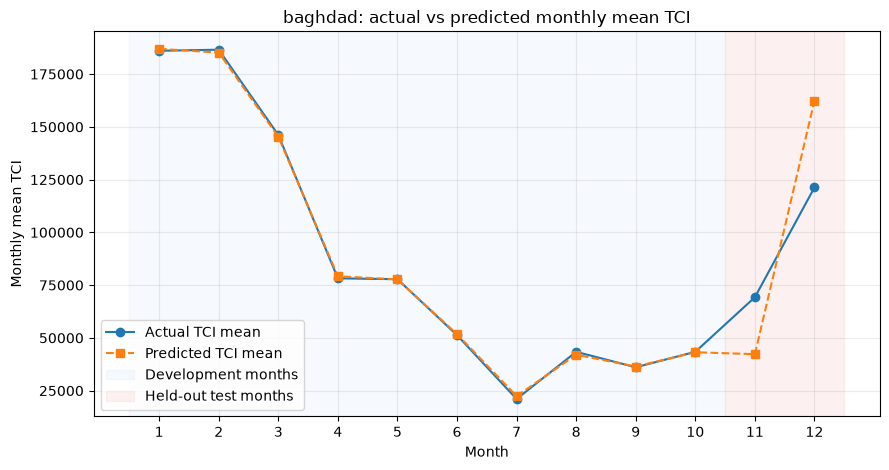

Saved monthly diagnostic figure for baghdad: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/baghdad/monthly_prediction_diagnostics_final_model.png


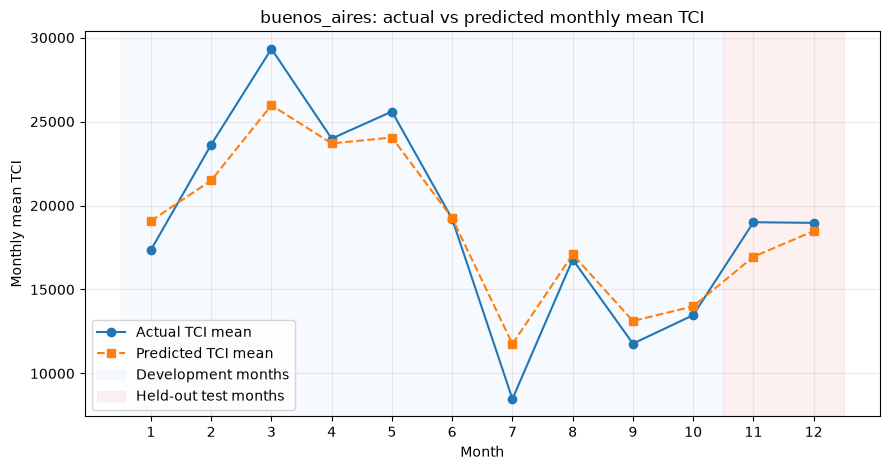

Saved monthly diagnostic figure for buenos_aires: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/buenos_aires/monthly_prediction_diagnostics_final_model.png


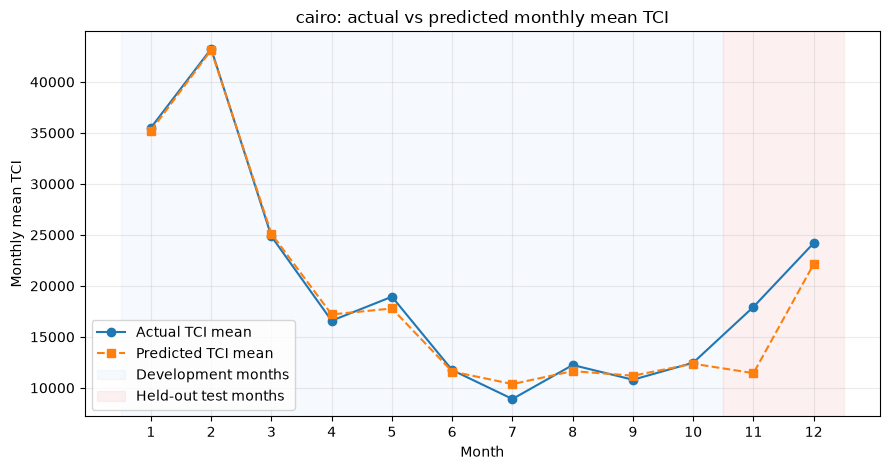

Saved monthly diagnostic figure for cairo: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/cairo/monthly_prediction_diagnostics_final_model.png


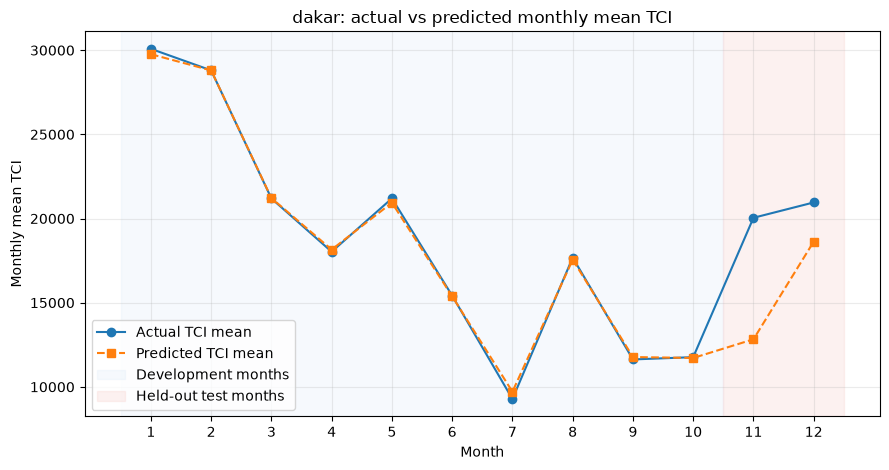

Saved monthly diagnostic figure for dakar: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/dakar/monthly_prediction_diagnostics_final_model.png


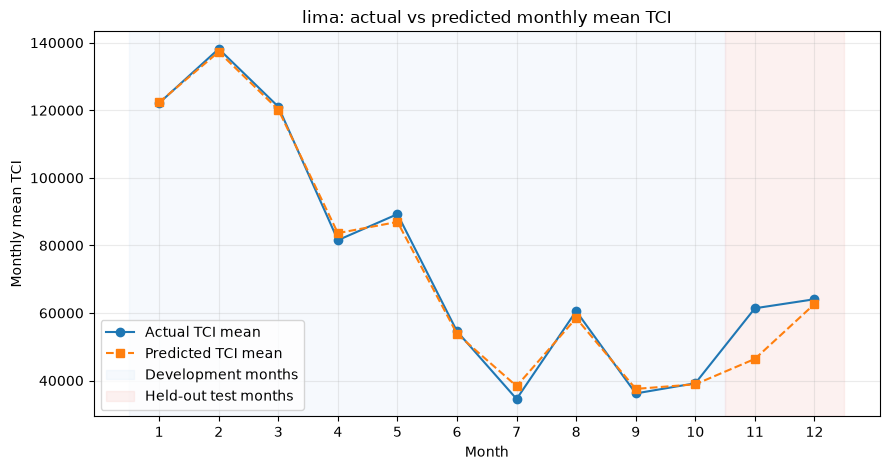

Saved monthly diagnostic figure for lima: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/lima/monthly_prediction_diagnostics_final_model.png


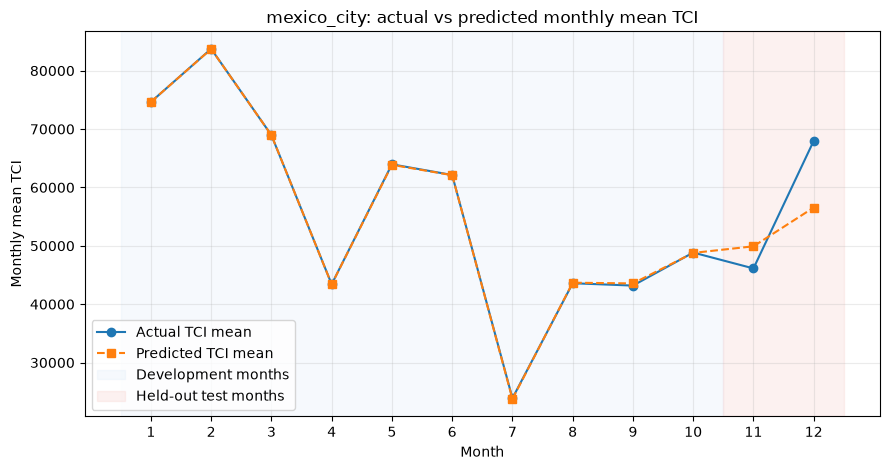

Saved monthly diagnostic figure for mexico_city: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/mexico_city/monthly_prediction_diagnostics_final_model.png


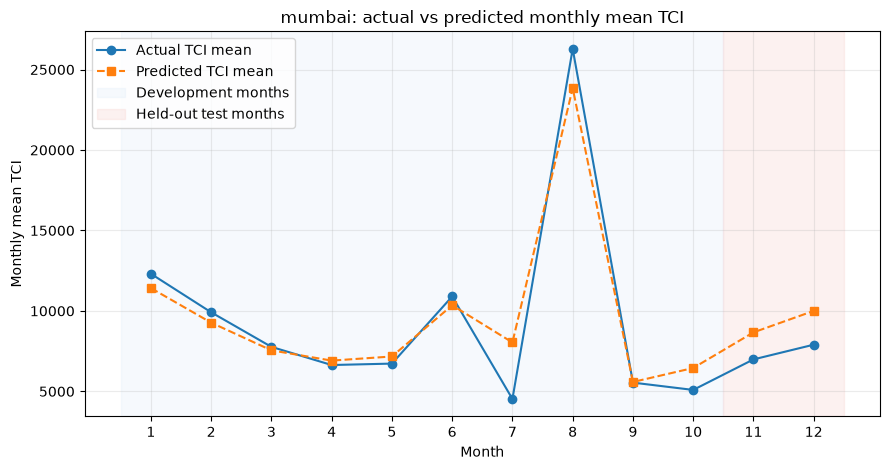

Saved monthly diagnostic figure for mumbai: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/mumbai/monthly_prediction_diagnostics_final_model.png


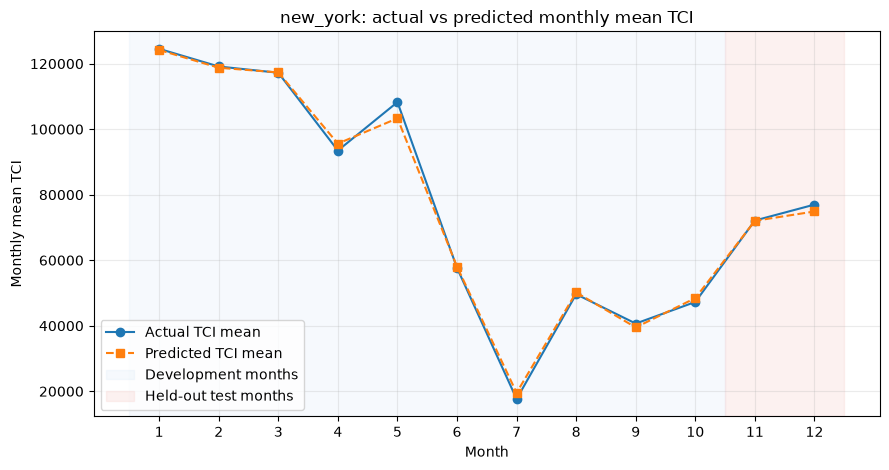

Saved monthly diagnostic figure for new_york: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month/new_york/monthly_prediction_diagnostics_final_model.png


In [9]:
def month_level_metrics(y_true: pd.Series, y_pred: pd.Series) -> dict:
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred).astype(float)
    residual = y_true - y_pred
    ss_res = float(np.sum(residual ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
    return {
        "actual_mean": y_true.mean(),
        "predicted_mean": y_pred.mean(),
        "bias_pred_minus_actual": (y_pred - y_true).mean(),
        "rmse": np.sqrt(np.mean(residual ** 2)),
        "mae": np.mean(np.abs(residual)),
        "r2": 1 - ss_res / ss_tot if ss_tot != 0 else np.nan,
        "actual_sd": y_true.std(),
    }


def append_monthly_rows(rows: list[dict], city: str, source: str, split_name: str, df: pd.DataFrame, y_pred: np.ndarray) -> None:
    temp = df[[YEAR_COL, MONTH_COL, TARGET_COL]].copy()
    temp[predicted_col()] = y_pred
    for (year, month), g in temp.groupby([YEAR_COL, MONTH_COL], dropna=False):
        metrics = month_level_metrics(g[TARGET_COL], g[predicted_col()])
        rows.append({
            "city": city,
            "source": source,
            "split": split_name,
            "year": int(year) if pd.notna(year) else year,
            "month": int(month) if pd.notna(month) else month,
            "rows": len(g),
            **metrics,
        })


SCENARIO_OUTPUT_ROOT = OUTPUT_ROOT / SCENARIO_ID
SCENARIO_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

diagnostic_rows = []
missing_diagnostic_outputs = []

for city in CITY_PANEL_FILES:
    city_output_dir = SCENARIO_OUTPUT_ROOT / city
    final_prediction_path = city_output_dir / "all_split_predictions_for_diagnostics.csv"

    if not final_prediction_path.exists():
        missing_diagnostic_outputs.append({"city": city, "missing": "all_split_predictions_for_diagnostics.csv"})
        continue

    final_pred_df = pd.read_csv(final_prediction_path)
    for split_name, split_df in final_pred_df.groupby("split", dropna=False):
        append_monthly_rows(
            diagnostic_rows,
            city=city,
            source="final_model_development_refit",
            split_name=split_name,
            df=split_df,
            y_pred=split_df[predicted_col()].to_numpy(),
        )

monthly_prediction_diagnostics = pd.DataFrame(diagnostic_rows)
diagnostic_path = SCENARIO_OUTPUT_ROOT / "monthly_prediction_diagnostics_final_model.csv"
monthly_prediction_diagnostics.to_csv(diagnostic_path, index=False)
print("Saved monthly prediction diagnostics:", diagnostic_path)

if missing_diagnostic_outputs:
    missing_diagnostic_df = pd.DataFrame(missing_diagnostic_outputs)
    print("\nCities skipped or partially skipped:")
    display(missing_diagnostic_df)

if monthly_prediction_diagnostics.empty:
    print("No diagnostic rows were created yet. Run the main model cell for at least one city first.")
else:
    display_cols = [
        "city",
        "source",
        "split",
        "month",
        "rows",
        "actual_mean",
        "predicted_mean",
        "bias_pred_minus_actual",
        "rmse",
        "mae",
        "r2",
        "actual_sd",
    ]
    display(monthly_prediction_diagnostics[display_cols].sort_values(["city", "month"]))

    test_month_summary = monthly_prediction_diagnostics.loc[
        monthly_prediction_diagnostics["split"].eq("test")
    ].copy()

    print("\nFinal-model test months only, sorted by RMSE:")
    display(test_month_summary.sort_values("rmse", ascending=False)[display_cols])

    for city, g in monthly_prediction_diagnostics.groupby("city"):
        fig, ax = plt.subplots(figsize=(9, 4.8))
        plot_g = g.sort_values("month")
        ax.plot(plot_g["month"], plot_g["actual_mean"], marker="o", label="Actual TCI mean")
        ax.plot(plot_g["month"], plot_g["predicted_mean"], marker="s", linestyle="--", label="Predicted TCI mean")
        ax.axvspan(0.5, 10.5, color="#DCEAF8", alpha=0.25, label="Development months")
        ax.axvspan(10.5, 12.5, color="#F6C9C6", alpha=0.25, label="Held-out test months")
        ax.set_xticks(range(1, 13))
        ax.set_xlabel("Month")
        ax.set_ylabel("Monthly mean TCI")
        ax.set_title(f"{city}: actual vs predicted monthly mean TCI")
        ax.grid(alpha=0.25)
        ax.legend(loc="best")
        fig.tight_layout()
        figure_path = SCENARIO_OUTPUT_ROOT / city / "monthly_prediction_diagnostics_final_model.png"
        fig.savefig(figure_path, dpi=200, bbox_inches="tight")
        plt.show()
        print(f"Saved monthly diagnostic figure for {city}: {figure_path}")


## 10. Prediction Helper

This helper loads a saved city model artifact and applies it to new data with the same feature structure.

The input `new_data` must contain the raw columns needed to rebuild the engineered predictors used by the selected model. The helper is intended for later prediction experiments after the model has already been trained and saved.


In [10]:
def predict_tci_for_city(city: str, new_data: pd.DataFrame) -> pd.DataFrame:
    artifact_path = SCENARIO_OUTPUT_ROOT / city / "model_artifact.joblib"
    if not artifact_path.exists():
        raise FileNotFoundError(f"Missing model artifact for {city}: {artifact_path}")

    artifact = joblib.load(artifact_path)
    feature_cols = artifact["feature_cols"]
    engineered_new_data, _ = add_engineered_features(new_data)
    missing_features = [col for col in feature_cols if col not in engineered_new_data.columns]
    if missing_features:
        raise ValueError(f"Missing prediction features for {city}: {missing_features}")

    out = engineered_new_data.copy()
    out[predicted_col()] = artifact["model"].predict(out[feature_cols])
    return out

print("Prediction helper ready: predict_tci_for_city(city, new_data)")
print("Artifacts live under:", SCENARIO_OUTPUT_ROOT)


Prediction helper ready: predict_tci_for_city(city, new_data)
Artifacts live under: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_with_geo_raw_full_range_v28_temporal_cv/raw_tci_full_range_temporal_cv_jan_oct_test_nov_dec_with_month
